# Prédire les crises d'épilepsie à partir de l'ECG
**Projet DESU Data Science - Alina Titova**

**Tuteur : Nicolas Rochet**

Dataset : [SeizeIT2 — OpenNeuro ds005873](https://openneuro.org/datasets/ds005873/versions/1.1.0)

In [1]:
# Tout d'abord on import les librairies nécessaires

import pandas as pd
import numpy as np
import mne
import sklearn 
import matplotlib.pyplot as plt
import os 
import glob
import random
import openpyxl as px 

# Dossier qui contient tous les patients (sub-001, sub-002, etc.)
DOSSIER_DATA = r"C:\Users\Alina\Desktop\AMU\DESU Data science\Projet\Data"

## 1.Fonctons

Dans un premier temps, j'ai créé des fonctions qui permettent de retrouver les fichiers d'un patient, de lister ses crises et d'afficher son signal cardiaque autour d'une crise.

Dans le dataset SeizeIT2, les annotations des crises (fichiers .tsv) sont rangées dans le dossier eeg de chaque patient, alors que le signal cardiaque (fichiers .edf) est dans un dossier ecg séparé. Les fonctions servent donc d'abord à relier ces deux dossiers.

| Fonction | Rôle |
|---|---|
| `dossier_eeg(patient)` | Donne le chemin du dossier 'eeg' d'un patient. |
| `liste_crises(patient)`  | Lit tous les fichiers '.tsv' du patient et renvoie un tableau avec toutes ses crises (début, durée, type). |
| `fichier_ecg(fichier_tsv)`  | À partir d'un fichier d'annotations, trouve le fichier ECG de la même run dans le dossier 'ecg'. |
| `charger_ecg(chemin_ecg, debut, fin)`  | Charge seulement le morceau d'ECG entre 'debut' et 'fin' (en secondes), pour ne pas lire tout le fichier. |
| `tracer_crise(patient, numero, marge)`  | Trace l'ECG autour d'une crise du patient, avec la crise en rouge. 'marge' indique combien de secondes afficher avant et après la crise. |

Ces fonctions sont utilisées dans la partie suivante pour visualiser le signal cardiaque pendant les crises.

In [ ]:
# Ici on définit quelques fonctions pour manipuler les fichiers EEG et ECG des patients.
# ECG est le coeur pour les prédictions, mais il est stocké dans un dossier séparé du dossier EEG. On va donc relier les deux.

# Cette fonction permet de trouver  le dossier spécifique à l'autre niveau.
def dossier_eeg(patient):
    """Donne le chemin du dossier eeg d'un patient."""
    return os.path.join(DOSSIER_DATA, patient, "ses-01", "eeg")

# Cette fonction permet de lister toutes les crises d'un patient. Les crises sont listées dans les fichiers *_events.tsv du dossier eeg.
def liste_crises(patient):
    """Lit tous les fichiers .tsv du patient et renvoie un tableau de TOUTES ses crises."""
    fichiers_tsv = sorted(glob.glob(os.path.join(dossier_eeg(patient), "*_events.tsv"))) 
    # La fonction glob.glob() permet de lister tous les fichiers qui correspondent à un motif donné. Ici, on cherche tous les fichiers qui se terminent par "_events.tsv" dans le dossier eeg du patient.

    toutes_les_crises = []
    for fichier in fichiers_tsv:
        tableau = pd.read_csv(fichier, sep="\t")
        crises = tableau[tableau["eventType"].str.startswith("sz", na=False)]
        for _, ligne in crises.iterrows():
            toutes_les_crises.append({
                "fichier_tsv": fichier,
                "debut": ligne["onset"],
                "duree": ligne["duration"],
                "type": ligne["eventType"],
            })
    return pd.DataFrame(toutes_les_crises)


# Après avoir trouvé les crises, on va chercher le fichier ECG correspondant à la même run. Le fichier ECG est stocké dans un dossier séparé du dossier EEG.
def fichier_ecg(fichier_tsv):
    """À partir du .tsv (dossier eeg), trouve le fichier ECG de la même run (dossier ecg)."""
    chemin = fichier_tsv.replace(os.sep + "eeg" + os.sep, os.sep + "ecg" + os.sep)
    return chemin.replace("_events.tsv", "_ecg.edf")


# Cette fonction permet de charger un morceau d'ECG entre deux temps donnés (en secondes). On utilise la librairie MNE pour lire les fichiers EDF.
def charger_ecg(chemin_ecg, debut, fin):
    """Charge seulement le morceau d'ECG entre 'debut' et 'fin' (en secondes)."""
    raw = mne.io.read_raw_edf(chemin_ecg, preload=False, verbose="ERROR") # preload=False pour ne pas charger tout le fichier en mémoire, juste les métadonnées. verbose="ERROR" pour ne pas afficher les warnings.
    canal = raw.ch_names[0]                                               # le fichier ECG n'a qu'un canal : "ECG SD"
    debut = max(0, debut)                                                 # pas avant le début de l'enregistrement
    fin = min(raw.times[-1], fin)                                         # pas après la fin
    morceau = raw.copy().pick([canal]).crop(tmin=debut, tmax=fin).load_data()
    signal, temps = morceau[:]                                            # MNE renvoie un tableau 2D (canaux x temps) et un tableau 1D (temps). Ici on n'a qu'un canal, donc signal est 2D avec une seule ligne.
    return temps + debut, signal[0], canal                                # on remet le vrai temps


def tracer_crise(patient, numero=0, marge=30):
    """Trace l'ECG autour d'une crise du patient, avec la crise en rouge."""
    crises = liste_crises(patient)
    if len(crises) == 0:
        print("Aucune crise chez", patient)
        return
    if numero >= len(crises):
        print(f"{patient} n'a que {len(crises)} crise(s). Choisissez un numéro entre 0 et {len(crises)-1}.")
        return

    crise = crises.iloc[numero]                 # iloc pour accéder à la ligne du DataFrame correspondant à la crise numéro 'numero'
    chemin = fichier_ecg(crise["fichier_tsv"])  
    if not os.path.exists(chemin):
        print("Pas de fichier ECG pour cette run :", chemin)
        return

    debut, duree = crise["debut"], crise["duree"]
    temps, signal, canal = charger_ecg(chemin, debut - marge, debut + duree + marge)

    plt.figure(figsize=(14, 4))
    plt.plot(temps, signal, linewidth=0.6, color="black")
    plt.axvspan(debut, debut + duree, color="red", alpha=0.3, label="Crise")
    plt.xlabel("Temps (s)")
    plt.ylabel(canal)
    plt.title(f"{patient} — crise {numero+1}/{len(crises)} — {os.path.basename(chemin)}")
    plt.legend()
    plt.show()

# Chaque patient a le nombre et la durée de ses runs différents. 
def duree_run(fichier_tsv):
    tableau = pd.read_csv(fichier_tsv, sep="\t")

    if "recordingDuration" in tableau.columns:
        return float(tableau["recordingDuration"].iloc[0])

    return np.nan

## 2. Répresentations

Ici, j'affiche le signal ECG autour de quelques crises, pour voir à quoi il ressemble et comment il change pendant une crise.

La fonction `liste_crises` affiche d'abord toutes les crises du patient `sub-091`. Ensuite, `tracer_crise` trace l'ECG autour de trois crises : les deux premières crises de `sub-091` et la première crise de `sub-037`. Pour chaque crise, le signal est affiché de 60 ou 100 secondes avant le début de la crise jusqu'à 60 ou 100 secondes après sa fin, et la crise est colorée en rouge.

Cette première visualisation permet de vérifier que les fichiers ECG et les annotations sont bien reliés, et d'observer les changements du signal pendant les crises (accélération du rythme, artefacts dus aux mouvements).


                                         fichier_tsv  debut  duree  \
0  C:\Users\Alina\Desktop\AMU\DESU Data science\P...  111.0   82.0   
1  C:\Users\Alina\Desktop\AMU\DESU Data science\P...  240.0   42.0   
2  C:\Users\Alina\Desktop\AMU\DESU Data science\P...  269.0   51.0   
3  C:\Users\Alina\Desktop\AMU\DESU Data science\P...  284.0   86.0   
4  C:\Users\Alina\Desktop\AMU\DESU Data science\P...  294.0   24.0   

           type  
0  sz_foc_ia_um  
1  sz_foc_ia_um  
2  sz_foc_ia_um  
3  sz_foc_ia_um  
4  sz_foc_ia_um  
Reading 0 ... 51712  =      0.000 ...   202.000 secs...


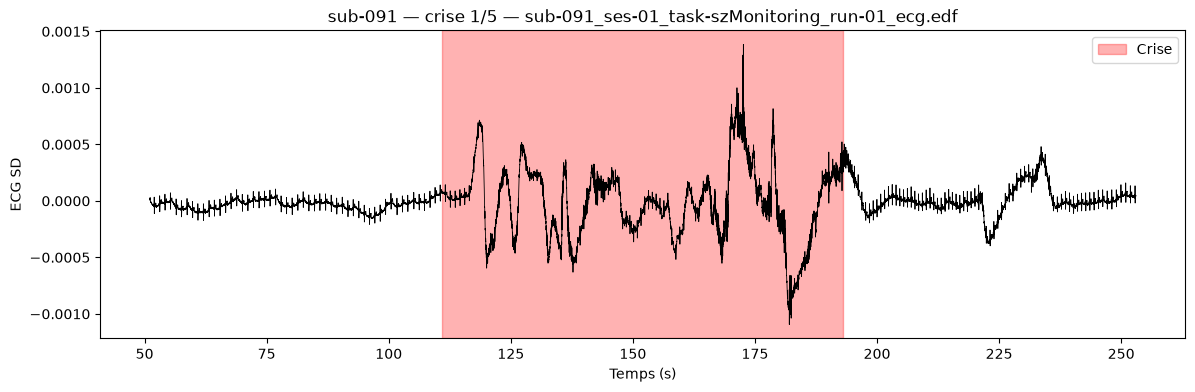

Reading 0 ... 41472  =      0.000 ...   162.000 secs...


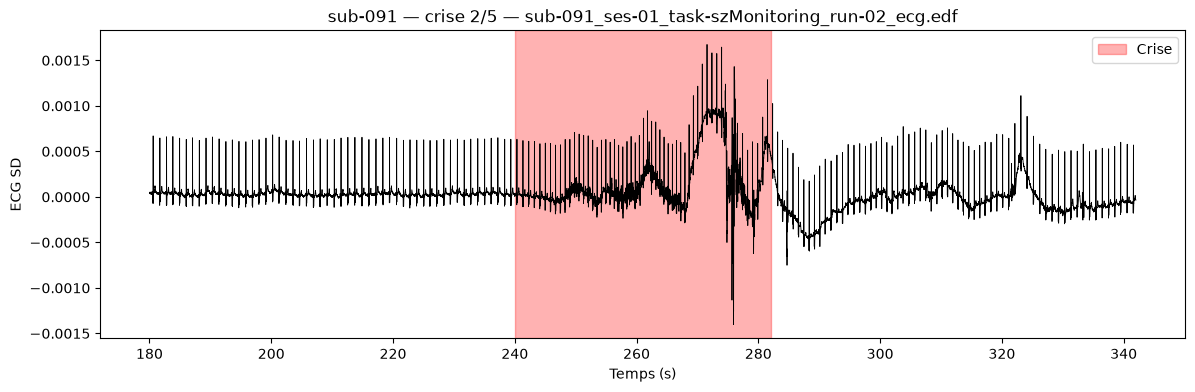

Reading 0 ... 84736  =      0.000 ...   331.000 secs...


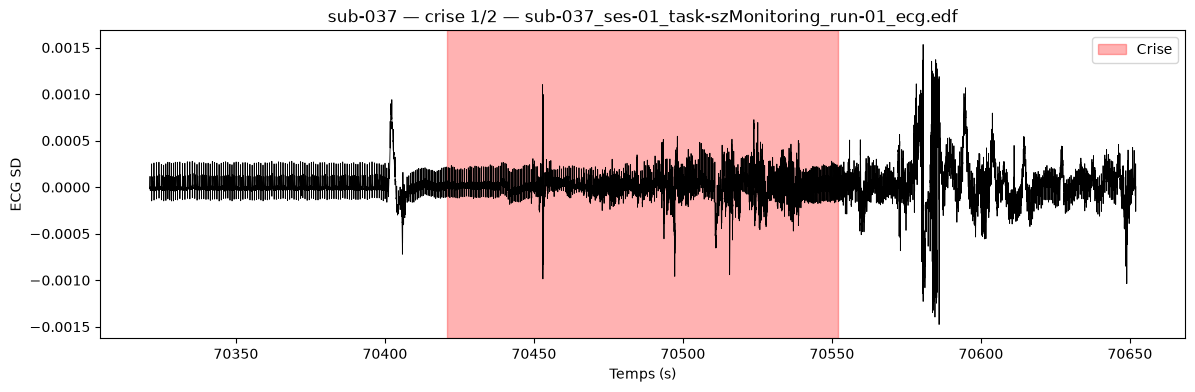

In [4]:
# Voir toutes les crises d'un patient
crises = liste_crises("sub-091")
print(crises)

# Tracer la 1re crise
tracer_crise("sub-091", marge=60)

# Tracer la 2e crise
tracer_crise("sub-091", numero=1, marge=60)

# Un autre patient, avec plus de marge
tracer_crise("sub-037", numero=0, marge=100)

## 3. Résumé

Après cette première exploration, je fais un résumé de tout le dataset avant de préparer les données pour les modèles.

Le résumé est calculé à deux niveaux :

- **par run** (chaque enregistrement) : durée de l'enregistrement, nombre de crises, durée totale des crises, pourcentage de temps en crise, types de crises, et présence ou non du fichier ECG ;
- **par patient** : les mêmes informations, additionnées sur toutes ses runs.

Les deux tableaux sont enregistrés dans un fichier Excel (`recap_crises.xlsx`).

Ce résumé permet de repérer les problèmes dans les données (par exemple les runs sans ECG) et de voir le pourcentage réel des crises et de sélectionner des patients.

In [ ]:
# Liste de tous les patients
patients = sorted(os.path.basename(d) for d in glob.glob(os.path.join(DOSSIER_DATA, "sub-*")))


def resume_runs_patient(patient):
    """Crée un résumé de chaque run d'un patient."""

    # Tous les fichiers TSV contient la description pour toutes les runs pour un patient
    fichiers_tsv = sorted(glob.glob(os.path.join(dossier_eeg(patient), "*_events.tsv")))

    # Toutes les crises du patient
    crises_patient = liste_crises(patient)

    lignes = []
    for tsv in fichiers_tsv: 

        # Crises appartenant uniquement à cette run
        crises_run = crises_patient[crises_patient["fichier_tsv"] == tsv]

        # ECG correspondant à cette run
        ecg = fichier_ecg(tsv)

        # Durée de cette run (en secondes)
        duree_totale = duree_run(tsv)

        # Durée totale passée en crise
        duree_crises = crises_run["duree"].sum()

        # Pourcentage de temps en crise
        if duree_totale > 0:
            pct_crise =  duree_crises / duree_totale * 100
        else:
            pct_crise = np.nan

        # Types de crises
        types_crises = ", ".join(crises_run["type"].unique())

        lignes.append({
            "patient": patient,
            "run": os.path.basename(tsv).split("_run-")[1].split("_")[0],   
            "duree_totale_s": duree_totale,
            "nb_crises": len(crises_run),
            "duree_crises_s": duree_crises,
            "pct_crise": pct_crise,
            "types_crises": types_crises,
            "ecg_present": os.path.exists(ecg),
        })

    return pd.DataFrame(lignes)


# Tableau par run, pour tous les patients 
recap_runs = pd.concat([resume_runs_patient(p) for p in patients], ignore_index=True)
print(recap_runs["duree_totale_s"].isna().sum(), "runs sans durée")
print((~recap_runs["ecg_present"]).sum(), "runs sans fichier ECG")

# Résumé par patient 
recap_patients = recap_runs.groupby("patient").agg(
    nb_runs=("run", "count"),
    duree_totale_s=("duree_totale_s", "sum"),
    nb_crises=("nb_crises", "sum"),
    duree_crises_s=("duree_crises_s", "sum"),
)
recap_patients["duree_totale_h"] = recap_patients["duree_totale_s"] / 3600    # en heures
recap_patients["pct_crise"] = 100 * recap_patients["duree_crises_s"] / recap_patients["duree_totale_s"]

# Résumé global 
duree_totale_s = recap_runs["duree_totale_s"].sum()
duree_crises_s = recap_runs["duree_crises_s"].sum()
recap_global = pd.DataFrame({
    "indicateur": ["Nombre de patients", "Nombre de runs", "Durée totale (h)", "Nombre de crises",
                   "Durée totale des crises (h)", "% de temps en crise", "Patients sans crise"],
    "valeur": pd.Series([len(recap_patients),
                         len(recap_runs),
                         round(duree_totale_s / 3600, 1),
                         recap_runs["nb_crises"].sum(),
                         round(duree_crises_s / 3600, 2),
                         round(100 * duree_crises_s / duree_totale_s, 3),
                         (recap_patients["nb_crises"] == 0).sum()], dtype=object),
})
print(recap_global.to_string(index=False))

# Sauvegarde en Excel : un seul fichier, 3 onglets, dans le dossier Projet
fichier_excel = os.path.join(os.path.dirname(DOSSIER_DATA), "recap_crises.xlsx")
with pd.ExcelWriter(fichier_excel) as excel:
    recap_global.to_excel(excel, sheet_name="Global", index=False)
    recap_patients.sort_values("pct_crise", ascending=False).round(3).to_excel(excel, sheet_name="Par patient")
    recap_runs.round(3).to_excel(excel, sheet_name="Par run", index=False)
print("Fichier Excel enregistré :", fichier_excel)

# Les 10 patients avec le plus de temps en crise
recap_patients.sort_values("pct_crise", ascending=False).head(10)

0 runs sans durée
46 runs sans fichier ECG
                 indicateur   valeur
         Nombre de patients      125
             Nombre de runs     2850
           Durée totale (h)  11626.2
           Nombre de crises      883
Durée totale des crises (h)    14.33
        % de temps en crise    0.123
        Patients sans crise        0
Fichier Excel enregistré : C:\Users\Alina\Desktop\AMU\DESU Data science\Projet\recap_crises.xlsx


,nb_runs,duree_totale_s,nb_crises,duree_crises_s,duree_totale_h,pct_crise
patient,,,,,,
sub-090,4,12780.0,4,1685.0,3.550000,13.184664
sub-091,5,3812.0,5,285.0,1.058889,7.476390
sub-087,25,74926.0,42,2617.0,20.812778,3.492780
sub-120,3,9009.0,10,118.0,2.502500,1.309801
sub-055,3,151971.0,8,1475.0,42.214167,0.970580
sub-060,4,174487.0,25,1279.0,48.468611,0.733006
sub-073,62,1010546.0,75,7260.0,280.707222,0.718424
sub-056,5,225839.0,13,1399.0,62.733056,0.619468
sub-094,49,157508.0,3,974.0,43.752222,0.618381


In [8]:
print(len(recap_runs[recap_runs["ecg_present"] == False]) / len(recap_runs) * 100)

1.6140350877192984


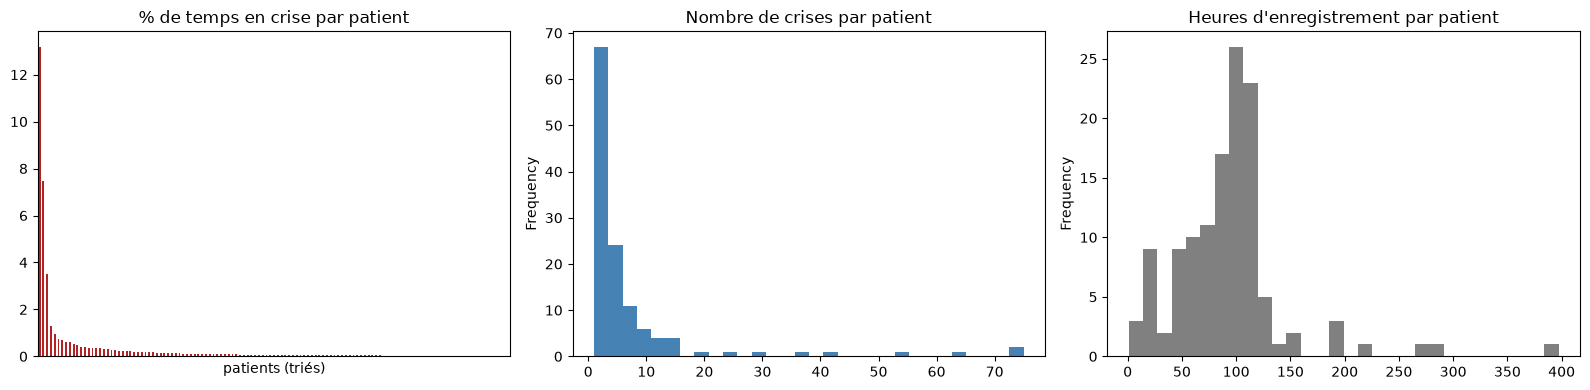

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
recap_patients["pct_crise"].sort_values(ascending=False).plot.bar(ax=axes[0], color="firebrick")
axes[0].set_title("% de temps en crise par patient")
axes[0].set_xticks([])
axes[0].set_xlabel("patients (triés)")
recap_patients["nb_crises"].plot.hist(ax=axes[1], bins=30, color="steelblue")
axes[1].set_title("Nombre de crises par patient")
recap_patients["duree_totale_h"].plot.hist(ax=axes[2], bins=30, color="grey")
axes[2].set_title("Heures d'enregistrement par patient")
plt.tight_layout()
plt.show()

## 4. Préparation des données : fenêtrage

Donc, maintenant, on va focaliser sur la préparation de la base des données pour l'entraînement du réseau des neurones et nos modèles.

Première étape est la découpage des données en fenêtres. Cela est fait parce que le signal ECG brut contient 250 valeurs par seconde, ce qui représente beaucoup trop de données pour être utilisé directement (le problème de la RAM de mon ordinateur) on le découpe donc en fenêtres de 10 secondes, et on résume chaque fenêtre par quelques mesures (comme la fréquence cardiaque).

Ce fenêtrage est effectué run par run avant l'agrégation, afin de conserver l'alignement avec les annotations de chaque run, de limiter la mémoire utilisée, et d'éviter de créer des fenêtres ou des intervalles cardiaques artificiels à la jonction entre deux enregistrements.

### Description des features

Chaque ligne du tableau correspond à une fenêtre de 10 secondes. On détecte d'abord les battements du cœur (pics R),
puis on calcule les intervalles RR (le temps entre deux battements en millisecondes).
Les RR impossibles (< 300 ms ou > 2000 ms, c'est-à-dire plus de 200 ou moins de 30 battements/min) sont retirés.

| Feature | Définition | Calcul | Sur quelle durée |
|---|---|---|---|
| `fc` | Fréquence cardiaque moyenne (battements/min) | 60 000 / moyenne des RR (en ms) | les 10 s de la fenêtre |
| `nb_battements` | Nombre de battements détectés | on compte les pics R | les 10 s de la fenêtre |
| `delta_fc` | Accélération du cœur par rapport à son niveau habituel | fc actuelle − médiane de la fc des 30 fenêtres précédentes (5 min, au moins 3 min valides) | les 5 min précédentes |
| `sdnn` | Variabilité globale du rythme (ms) | écart-type des RR | la dernière minute |
| `rmssd` | Variabilité d'un battement au suivant (ms) | racine de la moyenne des (RR suivant − RR précédent)² | la dernière minute |
| `pnn50` | % de battements qui changent beaucoup (%) | % des différences entre RR successifs supérieures à 50 ms | la dernière minute |
| `lf` | Puissance des oscillations lentes du rythme (ms²), 0,04–0,15 Hz | spectre des RR (méthode de Welch), puissance dans la bande | les 2 min précédentes |
| `hf` | Puissance des oscillations rapides du rythme (ms²), 0,15–0,4 Hz, liées à la respiration | spectre des RR (méthode de Welch), puissance dans la bande | les 2 min précédentes |
| `lf_hf` | Rapport entre oscillations lentes et rapides, souvent interprété comme l'équilibre accélérateur / frein du cœur | lf / hf | les 2 min précédentes |
| `cible` | Ce qu'on veut prédire : fraction de la fenêtre en crise | temps en crise dans la fenêtre / 10 s (0 = pas de crise, 1 = crise pendant toute la fenêtre) | les 10 s de la fenêtre |

**Remarques :**
- Toutes les features regardent uniquement **le passé** et la fenêtre actuelle, jamais le futur (pas de leakage).
- La `cible` vient des annotations des médecins (`.tsv`) ; les features viennent uniquement du signal ECG.
- SDNN, RMSSD et pNN50 ont besoin de plus de battements qu'il n'y en a en 10 s, d'où un historique d'1 minute.
- LF et HF ont besoin de voir plusieurs oscillations lentes (jusqu'à 25 s chacune), d'où 2 minutes, le minimum habituel.
- Quand le signal est mauvais pendant 10 ou 20 s, on recopie la dernière valeur connue ; au-delà, la valeur reste vide (NaN).

In [10]:
from scipy.signal import butter, sosfiltfilt, find_peaks, welch
# scipy.signal : pour filtrage, détection de pics et calcul du spectre de puissance
# scipy.signal.butter : pour créer un filtre passe-bande
# scipy.signal.sosfiltfilt : pour appliquer le filtre en avant et en arrière (filtrage sans décalage de phase)
# scipy.signal.find_peaks : pour détecter les pics R dans le signal ECG
# scipy.signal.welch : pour calculer le spectre de puissance d'un signal (méthode de Welch)

# Paramètres du fenêtrage
DUREE_FENETRE = 10        # secondes : une ligne du tableau = 10 s d'ECG
HISTORIQUE_VFC = 60       # secondes regardées en arrière pour SDNN, RMSSD, pNN50
HISTORIQUE_LF_HF = 120    # secondes regardées en arrière pour LF et HF (il faut au moins 2 min)
FS_RR = 4                 # Hz : on rééchantillonne les intervalles RR à 4 valeurs/s pour LF/HF

# Les battements cardiaques ont été détectés à l'aide d'une méthode inspirée de Pan–Tompkins. 
# Le signal ECG a été filtré entre 5 et 25 Hz, puis dérivé, mis au carré et lissé par une fenêtre glissante. 
# Les pics ont ensuite été détectés à l'aide d'un seuil adaptatif recalculé par blocs de 60 secondes.
def detecter_battements(signal, fs):
    """Trouve les battements du cœur (pics R) et renvoie leurs temps en secondes."""
    # 1. Filtre 5-25 Hz : garde la forme des pics R, enlève la dérive lente et le bruit
    sos = butter(3, [5, 25], btype="bandpass", fs=fs, output="sos")
    filtre = sosfiltfilt(sos, signal)
    # 2. Dérivée au carré puis lissage : les pics R deviennent de grosses bosses positives
    energie = np.diff(filtre, prepend=filtre[0]) ** 2
    taille_lissage = max(1, int(0.12 * fs))
    energie = np.convolve(energie, np.ones(taille_lissage) / taille_lissage, mode="same")
    # 3. Recherche des pics, avec un seuil recalculé toutes les 60 s
    pics = []
    taille_bloc = int(60 * fs)
    for debut in range(0, len(energie), taille_bloc):
        bloc = energie[debut:debut + taille_bloc]
        if len(bloc) < fs:
            continue
        seuil = 0.3 * np.percentile(bloc, 99)
        p, _ = find_peaks(bloc, height=seuil, distance=int(0.33 * fs))   # au plus ~180 battements/min
        pics.append(p + debut)

    
    if len(pics) == 0:
        return np.array([])
    pics = np.concatenate(pics)
    # 4. Recentrer chaque battement sur le vrai sommet du pic R (le lissage décale un peu la position)
    marge = int(0.075 * fs)                                   # on cherche le sommet à +/- 75 ms
    amplitude = np.abs(filtre)
    pics_corriges = []
    for p in pics:
        debut, fin = max(0, p - marge), min(len(amplitude), p + marge + 1)
        pics_corriges.append(debut + np.argmax(amplitude[debut:fin]))
    pics_corriges = np.unique(pics_corriges)                  # au cas où deux pics tombent au même sommet
    return pics_corriges / fs


def intervalles_rr(battements):
    """Temps entre deux battements (en ms), en enlevant les valeurs impossibles."""
    rr = np.diff(battements) * 1000          # en millisecondes
    temps_rr = battements[1:]                # moment où chaque intervalle se termine 
    garder = (rr > 300) & (rr < 2000)        # entre 30 et 200 battements/min
    return temps_rr[garder], rr[garder]


def vfc_temporelle(rr):
    """SDNN, RMSSD, pNN50 à partir d'une liste d'intervalles RR (ms)."""
    if len(rr) < 3:
        return np.nan, np.nan, np.nan
    differences = np.diff(rr)
    sdnn = np.std(rr, ddof=1)                              # variabilité globale
    rmssd = np.sqrt(np.mean(differences ** 2))             # variabilité battement à battement
    pnn50 = 100 * np.mean(np.abs(differences) > 50)        # % de différences > 50 ms
    return sdnn, rmssd, pnn50


def vfc_frequentielle(temps_rr, rr, n_fenetres):
    """LF et HF (ms²) pour chaque fenêtre, calculés sur les 2 minutes qui précèdent sa fin."""
    lf = np.full(n_fenetres, np.nan)
    hf = np.full(n_fenetres, np.nan)
    if len(rr) < 10:
        return lf, hf
    # Les RR ne tombent pas à intervalles réguliers : on les rééchantillonne à 4 Hz
    t_regulier = np.arange(0, n_fenetres * DUREE_FENETRE, 1 / FS_RR)
    rr_regulier = np.interp(t_regulier, temps_rr, rr)
    # Pour chaque fenêtre : le morceau des 2 dernières minutes
    n_points = HISTORIQUE_LF_HF * FS_RR
    fins = np.arange(1, n_fenetres + 1) * DUREE_FENETRE * FS_RR
    debuts = fins - n_points
    possibles = np.where(debuts >= 0)[0]            # les 2 premières minutes n'ont pas assez d'historique
    if len(possibles) == 0:
        return lf, hf
    morceaux = rr_regulier[debuts[possibles][:, None] + np.arange(n_points)]
    morceaux = morceaux - morceaux.mean(axis=1, keepdims=True)
    # Spectre de chaque morceau (tous d'un coup), puis puissance dans chaque bande
    freqs, puissance = welch(morceaux, fs=FS_RR, nperseg=min(256, n_points), axis=-1)
    pas = freqs[1] - freqs[0]
    lf[possibles] = puissance[:, (freqs >= 0.04) & (freqs < 0.15)].sum(axis=1) * pas
    hf[possibles] = puissance[:, (freqs >= 0.15) & (freqs < 0.40)].sum(axis=1) * pas
    # Si trop peu de battements dans les 2 minutes, le calcul n'est pas fiable
    nb_rr = np.searchsorted(temps_rr, fins / FS_RR) - np.searchsorted(temps_rr, np.maximum(0, fins / FS_RR - HISTORIQUE_LF_HF))
    peu_fiable = nb_rr < 0.5 * HISTORIQUE_LF_HF         # moins de 30 battements/min en moyenne
    lf[peu_fiable] = np.nan
    hf[peu_fiable] = np.nan
    return lf, hf


def cible_par_fenetre(n_fenetres, crises_run):
    """Pour chaque fenêtre : la fraction de temps en crise (0 = pas de crise, 1 = crise pendant les 10 s)."""
    debut_fen = np.arange(n_fenetres) * DUREE_FENETRE
    fin_fen = debut_fen + DUREE_FENETRE
    temps_en_crise = np.zeros(n_fenetres)
    for _, crise in crises_run.iterrows():
        chevauchement = np.minimum(fin_fen, crise["debut"] + crise["duree"]) - np.maximum(debut_fen, crise["debut"])
        temps_en_crise += np.clip(chevauchement, 0, None)
    return np.clip(temps_en_crise / DUREE_FENETRE, 0, 1)


def features_run(tsv, crises_run):
    """Découpe l'ECG d'une run en fenêtres de 10 s et calcule les features + la cible."""
    chemin = fichier_ecg(tsv)
    if not os.path.exists(chemin):
        return pd.DataFrame()                                  # pas d'ECG pour cette run

    # 1. Charger toute la run (notre fonction charger_ecg, de 0 jusqu'à la fin)
    temps, signal, canal = charger_ecg(chemin, 0, np.inf)
    fs = round(1 / (temps[1] - temps[0]))                     # fréquence d'échantillonnage (250 Hz)
    signal = np.nan_to_num(signal)
    n_fenetres = len(signal) // int(DUREE_FENETRE * fs)
    if n_fenetres == 0:
        return pd.DataFrame()

    # 2. Battements et intervalles RR (on n'a plus besoin du signal brut ensuite)
    battements = detecter_battements(signal, fs)
    del signal, temps
    temps_rr, rr = intervalles_rr(battements)

    # 3. Features fenêtre par fenêtre
    lignes = []
    for k in range(n_fenetres):
        debut_fen = k * DUREE_FENETRE
        fin_fen = debut_fen + DUREE_FENETRE

        # Les INTERVALLES RR de la fenêtre (recherche dans temps_rr) -> pour la fc
        i_debut, i_fin = np.searchsorted(temps_rr, [debut_fen, fin_fen])
        rr_fenetre = rr[i_debut:i_fin]

        # Les BATTEMENTS de la fenêtre (recherche dans battements) -> pour nb_battements
        j_debut, j_fin = np.searchsorted(battements, [debut_fen, fin_fen])

        # Les intervalles RR de la DERNIÈRE MINUTE -> pour sdnn, rmssd, pnn50
        i_histo = np.searchsorted(temps_rr, fin_fen - HISTORIQUE_VFC)
        sdnn, rmssd, pnn50 = vfc_temporelle(rr[i_histo:i_fin])

        lignes.append({
            "debut_s": debut_fen,
            "fc": 60000 / rr_fenetre.mean() if len(rr_fenetre) >= 2 else np.nan,  # battements/min
            "nb_battements": j_fin - j_debut,
            "sdnn": sdnn,
            "rmssd": rmssd,
            "pnn50": pnn50,
        })
    df = pd.DataFrame(lignes)

    # 4. Fréquentiel : LF, HF, LF/HF (sur les 2 dernières minutes)
    df["lf"], df["hf"] = vfc_frequentielle(temps_rr, rr, n_fenetres)
    df["lf_hf"] = df["lf"] / df["hf"].where(df["hf"] > 0)

    # 5. delta_fc : fc actuelle moins la fc habituelle des 5 minutes précédentes (30 fenêtres)
    #    (au moins 18 fenêtres valides sur 30, soit 3 minutes, sinon NaN)
    fc_habituelle = df["fc"].rolling(30, min_periods=18).median().shift(1)
    df["delta_fc"] = df["fc"] - fc_habituelle

    # 6. Petits trous (signal mauvais pendant 10 ou 20 s) : on recopie la dernière valeur connue.
    #    On ne regarde que le passé (ffill) : jamais le futur, pour éviter le leakage.
    #    Les trous plus longs et le début de la run restent vides (NaN) : on les traitera à la normalisation.
    colonnes = ["fc", "sdnn", "rmssd", "pnn50", "lf", "hf", "lf_hf", "delta_fc"]
    df[colonnes] = df[colonnes].ffill(limit=2)

    # 7. La cible
    df["cible"] = cible_par_fenetre(n_fenetres, crises_run)
    df.insert(0, "run", os.path.basename(tsv).split("_run-")[1].split("_")[0])
    return df

Reading 0 ... 30720  =      0.000 ...   120.000 secs...


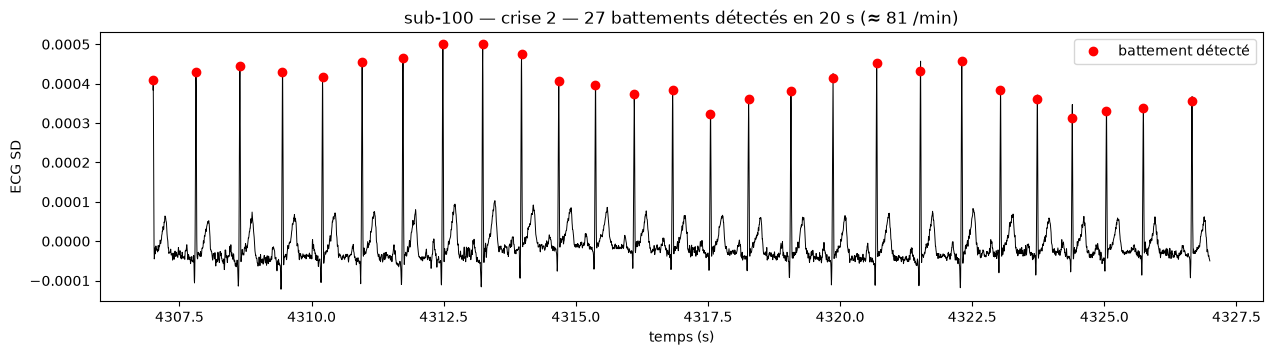

Reading 0 ... 30720  =      0.000 ...   120.000 secs...


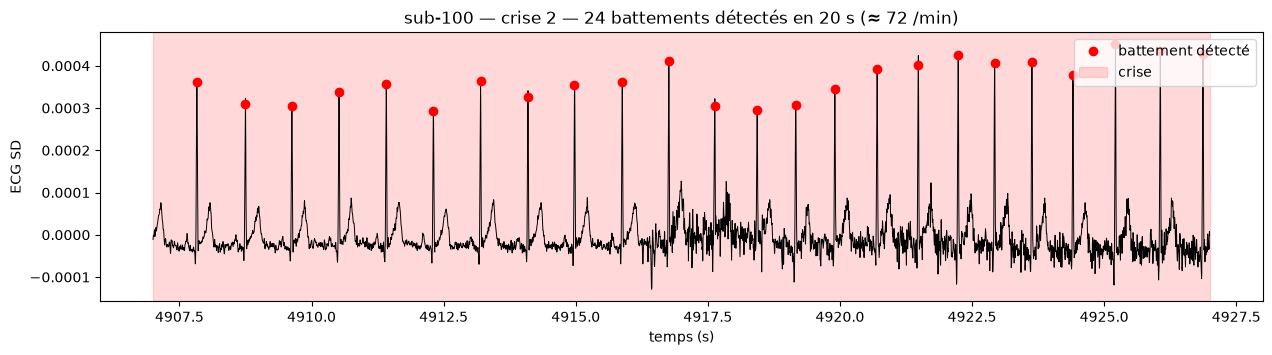

Reading 0 ... 30720  =      0.000 ...   120.000 secs...


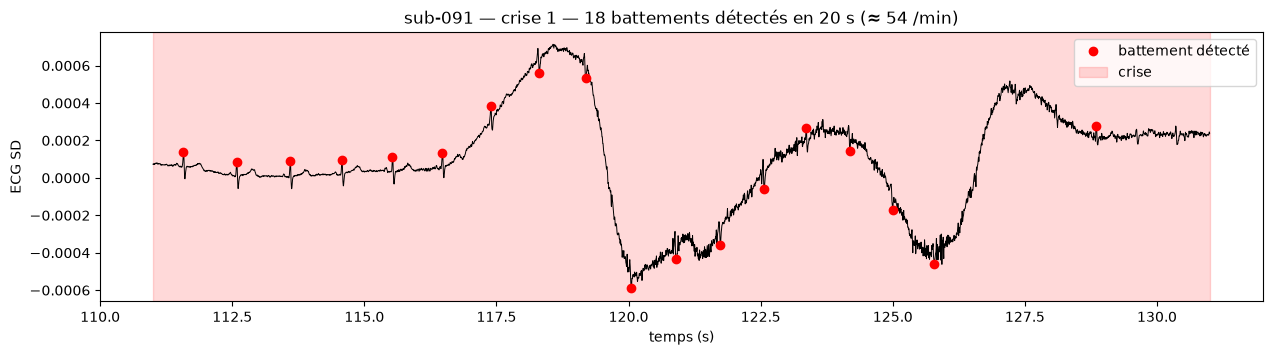

In [11]:
def verifier_battements(patient, numero=0, decalage_s=0, duree_s=20):
    """Trace l'ECG brut avec un point rouge sur chaque battement détecté.
    numero = numéro de la crise ; decalage_s = où regarder par rapport au début de la crise
    (0 = début de la crise, -600 = 10 minutes avant, hors crise)."""
    crises_patient = liste_crises(patient)
    crise = crises_patient.iloc[numero]
    chemin = fichier_ecg(crise["fichier_tsv"])
    if not os.path.exists(chemin):
        print("Pas d'ECG pour cette run")
        return

    debut = max(0, crise["debut"] + decalage_s)
    # On détecte sur 2 minutes (comme le seuil est recalculé par blocs de 60 s), puis on affiche duree_s secondes
    temps, signal, canal = charger_ecg(chemin, debut - 60, debut + 60)
    fs = round(1 / (temps[1] - temps[0]))
    battements = detecter_battements(np.nan_to_num(signal), fs) + temps[0]

    garder = (temps >= debut) & (temps < debut + duree_s)
    b = battements[(battements >= debut) & (battements < debut + duree_s)]
    plt.figure(figsize=(15, 3.5))
    plt.plot(temps[garder], signal[garder], color="black", linewidth=0.7)
    plt.plot(b, np.interp(b, temps, signal), "o", color="red", markersize=6, label="battement détecté")
    if decalage_s <= 0 < decalage_s + duree_s or crise["debut"] < debut < crise["debut"] + crise["duree"]:
        plt.axvspan(max(debut, crise["debut"]), min(debut + duree_s, crise["debut"] + crise["duree"]),
                    color="red", alpha=0.15, label="crise")
    plt.title(f"{patient} — crise {numero + 1} — {len(b)} battements détectés en {duree_s} s "
              f"(≈ {len(b) * 60 / duree_s:.0f} /min)")
    plt.xlabel("temps (s)")
    plt.ylabel(canal)
    plt.legend(loc="upper right")
    plt.show()


verifier_battements("sub-100", numero=1, decalage_s=-600)   # 10 min avant la crise (repos)
verifier_battements("sub-100", numero=1, decalage_s=0)      # début de la crise
verifier_battements("sub-091", numero=0, decalage_s=0)      # le patient au signal difficile

Reading 0 ... 908287  =      0.000 ...  3547.996 secs...


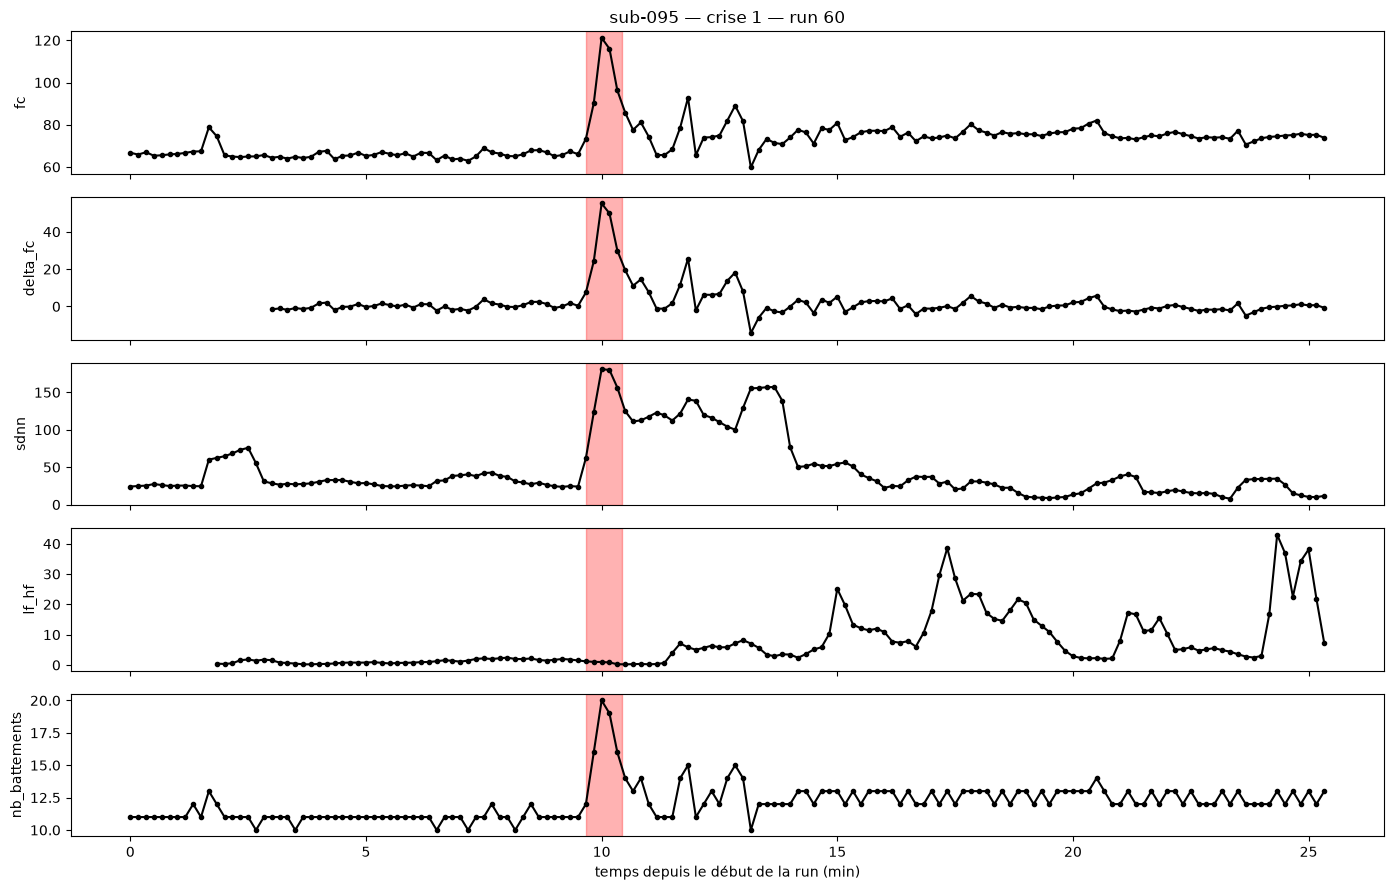

(354, 12)


,run,debut_s,fc,nb_battements,sdnn,rmssd,pnn50,lf,hf,lf_hf,delta_fc,cible
0,60,0,66.724587,11,24.136003,22.173680,0.000000,NaN,NaN,NaN,NaN,0.0
1,60,10,65.871345,11,24.825587,24.951124,5.000000,NaN,NaN,NaN,NaN,0.0
2,60,20,66.994449,11,25.361226,25.431787,3.225806,NaN,NaN,NaN,NaN,0.0
3,60,30,65.311171,11,27.463069,26.071876,2.380952,NaN,NaN,NaN,NaN,0.0
4,60,40,65.539178,11,26.118532,25.905575,3.773585,NaN,NaN,NaN,NaN,0.0


In [29]:
def tracer_features_crise(patient, numero=0, marge_min=10):
    """Calcule les features de la run qui contient la crise, et les trace autour de la crise."""
    crises_patient = liste_crises(patient)
    crise = crises_patient.iloc[numero]
    tsv = crise["fichier_tsv"]
    crises_run = crises_patient[crises_patient["fichier_tsv"] == tsv]
    df = features_run(tsv, crises_run)
    if len(df) == 0:
        print("Pas d'ECG pour cette run")
        return df

    # On garde seulement +/- marge_min minutes autour de la crise
    zoom = df[(df["debut_s"] > crise["debut"] - marge_min * 60) &
              (df["debut_s"] < crise["debut"] + crise["duree"] + marge_min * 60)]
    temps_min = zoom["debut_s"] / 60

    colonnes = ["fc", "delta_fc", "sdnn", "lf_hf", "nb_battements"]
    fig, axes = plt.subplots(len(colonnes), 1, figsize=(14, 9), sharex=True)
    for ax, col in zip(axes, colonnes):
        ax.plot(temps_min, zoom[col], color="black", marker=".")
        ax.axvspan(crise["debut"] / 60, (crise["debut"] + crise["duree"]) / 60, color="red", alpha=0.3)
        ax.set_ylabel(col)
    axes[0].set_title(f"{patient} — crise {numero + 1} — run {df['run'].iloc[0]}")
    axes[-1].set_xlabel("temps depuis le début de la run (min)")
    plt.tight_layout()
    plt.show()
    return df


df_test = tracer_features_crise("sub-095", numero=0, marge_min=15) 
print(df_test.shape)
df_test.head()

# 5. Agregation 

Le fenêtrage de la partie 4 fonctionne sur une seule run. Ici, je l'applique à toutes les runs des patients choisis, pour obtenir un seul grand tableau avec toutes les fenêtres, prêt pour les modèles.

La fonction `agreger_patient(patient)` fait trois choses :

1. pour chaque run du patient, elle calcule les fenêtres de 10 secondes, leurs features et leur cible avec `features_run` (les runs sans ECG sont ignorées) ;
2. elle colle toutes les runs bout à bout, dans l'ordre chronologique ;
3. elle ajoute une colonne `temps_patient_s`, qui donne le temps continu sur tout l'enregistrement du patient. Ce temps est nécessaire pour la partie suivante, où les données sont découpées dans l'ordre du temps.

Les tableaux de tous les patients sont ensuite réunis dans le tableau `donnees`.

Le calcul est long (plusieurs heures), donc le résultat est **enregistré dans le fichier `features_ecg.csv`**. Tant que `RECALCULER = False`, le notebook relit simplement ce fichier au lieu de tout recalculer. Il faut mettre `RECALCULER = True` seulement si on change le calcul des features ou la liste des patients.

In [30]:
# Paramètres
# Pour commencer : les 10 patients qui ont le plus de crises pour visualiser la situation 
# patients_choisis = recap_patients.sort_values("nb_crises", ascending=False).index[:10].tolist()
patients_choisis = patients      # <- tous les patients, quand tout marche

# Un seul fichier de sauvegarde, à côté du fichier Excel (le calcul est long, on ne le refait pas à chaque fois)
FICHIER_FEATURES = os.path.join(os.path.dirname(DOSSIER_DATA), "features_ecg.csv")
RECALCULER = False     # mettre True pour forcer un nouveau calcul (par ex. si on change les features)


def agreger_patient(patient):
    """Fenêtre chaque run du patient (features_run), puis colle toutes les runs bout à bout, dans l'ordre."""
    crises_patient = liste_crises(patient)
    fichiers_tsv = sorted(glob.glob(os.path.join(dossier_eeg(patient), "*_events.tsv")))

    morceaux = []
    for tsv in fichiers_tsv:
        crises_run = crises_patient[crises_patient["fichier_tsv"] == tsv]   # crises de cette run seulement
        df_run = features_run(tsv, crises_run)                              # fenêtrage + features + cible. This function returns a DataFrame with features for each window of the run.
        if len(df_run) > 0:                                                 # run sans ECG -> ignorée
            morceaux.append(df_run)

    if len(morceaux) == 0:
        return pd.DataFrame()

    df_patient = pd.concat(morceaux, ignore_index=True)              # on colle les runs bout à bout
    df_patient.insert(0, "patient", patient)
    df_patient["temps_patient_s"] = np.arange(len(df_patient)) * DUREE_FENETRE   # temps continu sur tout le patient
    return df_patient


if os.path.exists(FICHIER_FEATURES) and not RECALCULER:
    donnees = pd.read_csv(FICHIER_FEATURES, dtype={"run": str})
    print("Features relues depuis", FICHIER_FEATURES)
else:
    tous = []
    for i, patient in enumerate(patients_choisis):
        print(f"[{i + 1}/{len(patients_choisis)}] {patient}")
        df_patient = agreger_patient(patient)
        if len(df_patient) > 0:
            tous.append(df_patient)
    donnees = pd.concat(tous, ignore_index=True)
    donnees.to_csv(FICHIER_FEATURES, index=False)
    print("Features enregistrées dans", FICHIER_FEATURES)

print(donnees.shape)
print(f"{donnees['patient'].nunique()} patients | {len(donnees)} fenêtres | "
      f"{(donnees['cible'] > 0).sum()} fenêtres avec crise ({100 * (donnees['cible'] > 0).mean():.2f} %)")
donnees.head()

[1/125] sub-001
Reading 0 ... 16721663  =      0.000 ... 65318.996 secs...
Reading 0 ... 5072895  =      0.000 ... 19815.996 secs...
Reading 0 ... 16634623  =      0.000 ... 64978.996 secs...
Reading 0 ... 5429503  =      0.000 ... 21208.996 secs...
Reading 0 ... 16002815  =      0.000 ... 62510.996 secs...
Reading 0 ... 5169151  =      0.000 ... 20191.996 secs...
Reading 0 ... 7556607  =      0.000 ... 29517.996 secs...
Reading 0 ... 13178367  =      0.000 ... 51477.996 secs...
Reading 0 ... 12456191  =      0.000 ... 48656.996 secs...
[2/125] sub-002
Reading 0 ... 2913279  =      0.000 ... 11379.996 secs...
Reading 0 ... 6142463  =      0.000 ... 23993.996 secs...
Reading 0 ... 10005503  =      0.000 ... 39083.996 secs...
Reading 0 ... 1386751  =      0.000 ...  5416.996 secs...
Reading 0 ... 19957503  =      0.000 ... 77958.996 secs...
Reading 0 ... 20697343  =      0.000 ... 80848.996 secs...
Reading 0 ... 1104895  =      0.000 ...  4315.996 secs...
Reading 0 ... 12174591  =      0

,patient,run,debut_s,fc,nb_battements,sdnn,rmssd,pnn50,lf,hf,lf_hf,delta_fc,cible,temps_patient_s
0,sub-001,01,0,72.738753,13,10.108791,15.976167,0.0,NaN,NaN,NaN,NaN,0.0,0
1,sub-001,01,10,73.200953,12,10.805689,14.248096,0.0,NaN,NaN,NaN,NaN,0.0,10
2,sub-001,01,20,72.652739,12,10.092496,13.881524,0.0,NaN,NaN,NaN,NaN,0.0,20
3,sub-001,01,30,72.595510,12,9.465981,13.326152,0.0,NaN,NaN,NaN,NaN,0.0,30
4,sub-001,01,40,72.424361,12,9.240843,13.015315,0.0,NaN,NaN,NaN,NaN,0.0,40


# 6. TimeSeriesSplit

Pour évaluer les modèles, il faut séparer les données en une partie **TRAIN** et une partie **TEST**. Ici, on ne peut pas mélanger les fenêtres au hasard : deux fenêtres qui se suivent sont presque identiques, et certaines features utilisent les minutes précédentes. Si on mélangeait, le modèle verrait pendant l'entraînement des fenêtres presque identiques à celles du test.

J'utilise donc `TimeSeriesSplit` de scikit-learn, qui respecte l'ordre du temps : le modèle apprend sur le passé et il est testé sur le futur, comme ce serait le cas en vrai.

Le découpage est fait **patient par patient** :

- l'enregistrement de chaque patient est coupé en 4 parties égales, dans l'ordre du temps ;
- **pli 1** : train = 1re partie, test = 2e partie ;
- **pli 2** : train = parties 1 et 2, test = 3e partie ;
- **pli 3** : train = parties 1, 2 et 3, test = 4e partie.

Le train grandit donc à chaque pli, et chaque pli contient des données de tous les patients. Les morceaux de tous les patients sont ensuite réunis pour former le train et le test de chaque pli.

Un **trou de 30 fenêtres** (5 minutes, paramètre `gap`) est laissé entre le train et le test. Comme chaque séquence regarde les 5 minutes précédentes, ce trou évite que les premières séquences du test utilisent des fenêtres qui ont servi à l'entraînement.

Les patients avec moins de 300 fenêtres (50 minutes d'enregistrement) sont ignorés, car ils sont trop courts pour être découpés.

In [31]:
from sklearn.model_selection import TimeSeriesSplit

N_PLIS = 3                # nombre de découpages
LONGUEUR_SEQUENCE = 30    # le LSTM regardera 30 fenêtres = 5 minutes (sert de "trou" entre train et test)
# On utilise 30 fenêtres pour que le modèle ne regarde pas juste avant la crise, mais un peu plus loin dans le passé. Cela permet d'éviter le leakage temporel.

tss = TimeSeriesSplit(n_splits=N_PLIS, gap=LONGUEUR_SEQUENCE)

# Pour chaque pli : la liste des lignes de "donnees" qui vont dans le train et dans le test
plis = [{"train": [], "test": []} for _ in range(N_PLIS)]

for patient in donnees["patient"].unique():
    lignes_patient = donnees.index[donnees["patient"] == patient].to_numpy()   # déjà dans l'ordre du temps
    if len(lignes_patient) < 10 * LONGUEUR_SEQUENCE:                           # patient trop court pour être découpé
        print(patient, ": trop peu de fenêtres, ignoré")
        continue
    for k, (i_train, i_test) in enumerate(tss.split(lignes_patient)):
        plis[k]["train"].extend(lignes_patient[i_train])
        plis[k]["test"].extend(lignes_patient[i_test])

# Résumé de chaque pli
for k, pli in enumerate(plis):
    train = donnees.loc[pli["train"]]
    test = donnees.loc[pli["test"]]
    print(f"Pli {k + 1} : train {len(train):>7} fenêtres ({(train['cible'] > 0).sum()} avec crise) | "
          f"test {len(test):>7} fenêtres ({(test['cible'] > 0).sum()} avec crise)")

Pli 1 : train 1010484 fenêtres (984 avec crise) | test 1014019 fenêtres (1700 avec crise)
Pli 2 : train 2024503 fenêtres (2683 avec crise) | test 1014019 fenêtres (1962 avec crise)
Pli 3 : train 3038522 fenêtres (4653 avec crise) | test 1014019 fenêtres (1131 avec crise)


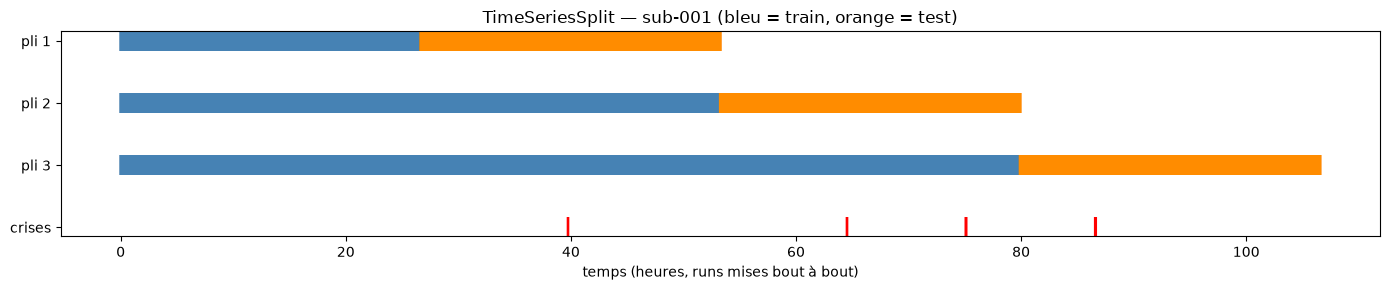

In [ ]:
# Dessin du découpage pour un patient : bleu = train, orange = test, rouge = crises
patient_exemple = donnees["patient"].iloc[0]   # on prend le premier patient de la liste pour l'exemple
lignes_exemple = donnees.index[donnees["patient"] == patient_exemple]

fig, ax = plt.subplots(figsize=(14, 3))
for k, pli in enumerate(plis):
    y = N_PLIS - k
    train = np.intersect1d(pli["train"], lignes_exemple)
    test = np.intersect1d(pli["test"], lignes_exemple)
    ax.scatter(donnees.loc[train, "temps_patient_s"] / 3600, [y] * len(train), color="steelblue", marker="|", s=200)
    ax.scatter(donnees.loc[test, "temps_patient_s"] / 3600, [y] * len(test), color="darkorange", marker="|", s=200)
crises_exemple = donnees.loc[lignes_exemple][donnees.loc[lignes_exemple, "cible"] > 0]
ax.scatter(crises_exemple["temps_patient_s"] / 3600, [0] * len(crises_exemple), color="red", marker="|", s=200)
ax.set_yticks(range(N_PLIS + 1))
ax.set_yticklabels(["crises"] + [f"pli {k}" for k in range(N_PLIS, 0, -1)])
ax.set_xlabel("temps (heures, runs mises bout à bout)")
ax.set_title(f"TimeSeriesSplit — {patient_exemple} (bleu = train, orange = test)")
plt.tight_layout()
plt.show()

# 7.Préparation pour l'entraînement

### Choix des features

Dans une première version sur 29 patients, l'analyse d'importance (Ridge, Random Forest, permutation) avait montré que 4 features étaient les plus utiles : `delta_fc`, `nb_battements`, `sdnn` et `fc`. LF, HF, LF/HF, RMSSD et pNN50 apportaient peu.

Maintenant que les 125 patients sont utilisés, je reprends **toutes les features (9)**, pour vérifier si ce choix reste valable sur l'ensemble du dataset. Le paramètre `UTILISER_TOUTES` permet de passer facilement de 9 à 4 features, pour comparer les deux versions.

LF, HF et LF/HF ont des valeurs très étalées (de quelques ms² à plusieurs milliers). Je leur applique un **logarithme**, pour les ramener à une échelle comparable aux autres features.

### Construction des séquences

Chaque exemple donné aux modèles est une **séquence de 30 fenêtres** (5 minutes). Une séquence doit rester dans une seule run : on ne colle pas la fin d'un enregistrement avec le début du suivant.

La cible est la fraction de crise dans la fenêtre située `HORIZON` fenêtres après la fin de la séquence :

- `HORIZON = 0` : **détection**, le modèle reconnaît la crise en cours ;
- `HORIZON = 6` : **prédiction**, le modèle doit annoncer la crise 1 minute à l'avance.

### Normalisation

Chaque feature est **centrée et réduite patient par patient**, car le rythme cardiaque normal varie beaucoup d'une personne à l'autre. La moyenne et l'écart-type sont calculés **sur le train seulement**, pour que le modèle n'utilise aucune information du test. Les valeurs manquantes sont remplacées par 0 (c'est-à-dire la valeur moyenne du patient), et les valeurs extrêmes sont limitées entre -10 et 10.

### Déséquilibre des classes

- **Train** : on garde toutes les séquences avec crise, et on tire au hasard 20 fois plus de séquences sans crise. Sans ça, le modèle verrait presque uniquement des séquences sans crise et apprendrait à toujours répondre « pas de crise ».
- **Test** : on ne rééquilibre **pas**, pour qu'il ressemble à la vraie vie, où les crises sont rares. On garde seulement 1 séquence sur 6 (une par minute), pour limiter la mémoire nécessaire.

La graine `GRAINE = 42` permet d'obtenir les mêmes tirages au hasard à chaque exécution.

In [81]:
# Paramètres 
# Avant j'ai testé avec mes 10 ou 29 patients avec plus de crises enregistrées et j'ai retenu 4 features les plus importantes (voir l'analyse d'importance)
TOUTES_LES_FEATURES = ["fc", "nb_battements", "delta_fc", "sdnn", "rmssd", "pnn50", "lf", "hf", "lf_hf"]
MEILLEURES_FEATURES = ["delta_fc", "nb_battements", "sdnn", "fc"]   # choisies sur 29 patients
UTILISER_TOUTES = True
FEATURES = TOUTES_LES_FEATURES if UTILISER_TOUTES else MEILLEURES_FEATURES
print(f"{len(FEATURES)} features utilisées : {FEATURES}")

HORIZON = 0                 # 0 = détecter la crise en cours ; 6 = anticiper 1 minute à l'avance
NEGATIFS_PAR_POSITIF = 20   # pour le train : 20 séquences sans crise pour 1 séquence avec crise, pour éviter le déséquilibre
PAS_TEST = 6                # pour le test : on garde 1 séquence sur 6 (= 1 par minute), pour la RAM
GRAINE = 42                 # pour avoir les mêmes résultats à chaque fois
np.random.seed(GRAINE)

# Copie des features (on ne modifie pas "donnees", on peut donc relancer la cellule sans problème)
valeurs = donnees[FEATURES].copy()
valeurs["patient"] = donnees["patient"]

# ---------- Les fins de séquence possibles ----------
# Une séquence = les 30 fenêtres qui finissent à une ligne donnée. Elle doit rester dans UNE SEULE run.
position = donnees.groupby(["patient", "run"]).cumcount().to_numpy()                 # n° de la fenêtre dans sa run
taille_run = donnees.groupby(["patient", "run"])["run"].transform("size").to_numpy()  # nb de fenêtres de la run
fin_possible = (position >= LONGUEUR_SEQUENCE - 1) & (position + HORIZON < taille_run)
print(f"{fin_possible.sum()} séquences possibles sur {len(donnees)} fenêtres")


def normaliser(lignes_train):
    """Centre-réduit chaque feature patient par patient, avec la moyenne et l'écart-type du TRAIN seulement."""
    moyennes = valeurs.loc[lignes_train].groupby("patient")[FEATURES].mean()
    ecarts = valeurs.loc[lignes_train].groupby("patient")[FEATURES].std()
    m = moyennes.reindex(donnees["patient"]).to_numpy()
    e = ecarts.reindex(donnees["patient"]).to_numpy()
    X = (valeurs[FEATURES].to_numpy() - m) / (e + 1e-8)
    X = np.nan_to_num(X, nan=0.0)                                      # NaN -> 0 = la valeur moyenne
    X = np.clip(X, -10, 10)                                            # on limite les valeurs extrêmes
    return X.astype(np.float32)


def construire_sequences(X, fins):
    """X : (nb_sequences, 30, nb_features) ; y : (nb_sequences,)."""
    decalages = np.arange(-LONGUEUR_SEQUENCE + 1, 1)          # -29, -28, ..., 0
    X_seq = X[fins[:, None] + decalages]
    y_seq = donnees["cible"].to_numpy(dtype=np.float32)[fins + HORIZON]
    return X_seq, y_seq


def fins_du_pli(pli):
    """Fins de séquence du train (rééquilibré) et du test (1 sur PAS_TEST)."""
    rng = np.random.default_rng(GRAINE)
    cible = donnees["cible"].to_numpy()
    fins_train = np.array(pli["train"])[fin_possible[pli["train"]]]
    fins_test = np.array(pli["test"])[fin_possible[pli["test"]]]
    # Train : toutes les séquences avec crise + NEGATIFS_PAR_POSITIF fois plus sans crise
    positifs = fins_train[cible[fins_train + HORIZON] > 0]
    negatifs = fins_train[cible[fins_train + HORIZON] == 0]
    n_neg = min(len(negatifs), max(1, len(positifs)) * NEGATIFS_PAR_POSITIF)
    fins_train = rng.permutation(np.concatenate([positifs, rng.choice(negatifs, n_neg, replace=False)]))
    # Test : on ne rééquilibre PAS (il doit ressembler à la vraie vie), on en garde juste 1 sur PAS_TEST
    return fins_train, fins_test[::PAS_TEST]

9 features utilisées : ['fc', 'nb_battements', 'delta_fc', 'sdnn', 'rmssd', 'pnn50', 'lf', 'hf', 'lf_hf']
3974997 séquences possibles sur 4056261 fenêtres


# 8. Les modèles

Tous les modèles reçoivent les mêmes séquences (30 fenêtres × 9 features) et donnent un nombre entre 0 et 1 : la fraction de la fenêtre en crise.

1. **Toujours 0** et **Moyenne** : deux modèles de référence très simples. Le premier répond toujours « pas de crise », le second répond toujours la moyenne de la cible du train. Un vrai modèle doit faire mieux qu'eux pour être utile.

2. **Régression linéaire (Ridge)** : chaque séquence est « aplatie » en une seule ligne de 30 × 9 = 270 nombres. Le modèle fait une somme pondérée de ces nombres. La régularisation Ridge (`alpha = 1`) évite que les poids deviennent trop grands.

3. **Random Forest** : 200 arbres de décision, chacun appris sur une partie des données et des features. La prédiction finale est la moyenne des 200 arbres. Chaque feuille contient au moins 5 exemples, pour éviter que les arbres apprennent par cœur.

4. **Boosting** (HistGradientBoosting) : 200 petits arbres construits l'un après l'autre, chacun corrige les erreurs des précédents (taux d'apprentissage de 0,1).

5. **LSTM** : un réseau de neurones qui lit les 30 fenêtres **dans l'ordre**, et peut donc tenir compte de l'évolution du signal dans le temps. Architecture : une couche LSTM de 32 unités, un dropout de 20 % pour limiter le sur-apprentissage, une couche de 16 neurones, et une sortie sigmoïde (entre 0 et 1). Entraînement avec Adam (taux d'apprentissage 0,001) en minimisant la MSE, par lots de 256 séquences, pendant 50 époques au maximum. L'entraînement s'arrête si l'erreur sur 15 % des données de train mises de côté ne s'améliore plus pendant 5 époques.

Ridge, Random Forest et Boosting ne connaissent pas l'ordre des fenêtres : pour eux, les 270 nombres sont juste une liste. Seul le LSTM tient compte de l'ordre.

Les prédictions de Ridge et des arbres sont limitées entre 0 et 1, comme la cible.

**Évaluation** : MSE et MAE sur tout le test, MSE et MAE seulement pendant les crises, et AUC (capacité à distinguer les fenêtres avec et sans crise ; 0,5 = hasard, 1 = parfait).

In [82]:
import tensorflow as tf
from tensorflow import keras
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, roc_auc_score
tf.random.set_seed(GRAINE)


def entrainer_lineaire(X_train, y_train):
    """Régression linéaire (Ridge) : on 'aplatit' chaque séquence en une seule ligne de 30 x X nombres."""
    modele = Ridge(alpha=1.0)
    modele.fit(X_train.reshape(len(X_train), -1), y_train)
    return modele


def predire_lineaire(modele, X):
    return np.clip(modele.predict(X.reshape(len(X), -1)), 0, 1)   # la cible est entre 0 et 1


def entrainer_lstm(X_train, y_train):
    """LSTM basique : lit les 30 fenêtres dans l'ordre et sort un nombre entre 0 et 1."""
    modele = keras.Sequential([
        keras.Input(shape=(X_train.shape[1], X_train.shape[2])),
        keras.layers.LSTM(32),                         # la "mémoire" du modèle
        keras.layers.Dropout(0.2),                     # limite le sur-apprentissage
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid"),   # sortie entre 0 et 1, comme la cible
    ])
    modele.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse", metrics=["mae"])
    arret = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)   # s'arrête quand ça ne progresse plus
    historique = modele.fit(X_train, y_train, validation_split=0.15, epochs=15,
                            batch_size=256, callbacks=[arret], verbose=2)
    return modele, historique


def evaluer(nom, y_vrai, y_pred, numero_pli):
    """MSE et MAE sur tout le test, et seulement pendant les crises, + AUC."""
    crise = y_vrai > 0
    return {
        "pli": numero_pli,
        "modele": nom,
        "MSE": mean_squared_error(y_vrai, y_pred),
        "MAE": mean_absolute_error(y_vrai, y_pred),
        "MSE_crise": mean_squared_error(y_vrai[crise], y_pred[crise]) if crise.any() else np.nan,
        "MAE_crise": mean_absolute_error(y_vrai[crise], y_pred[crise]) if crise.any() else np.nan,
        "AUC": roc_auc_score(crise, y_pred) if 0 < crise.sum() < len(crise) else np.nan,
    }

In [83]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# Noms des colonnes de X (les features)
NOMS_FEATURES = FEATURES


def aplatir(X):
    """(nb_sequences, 30, X) -> (nb_sequences, 30 * X) : une ligne par séquence, pour Ridge et les arbres."""
    return X.reshape(len(X), -1)


def entrainer_foret(X_train, y_train):
    """Random Forest : 200 arbres de décision, chacun appris sur une partie des données ; on fait la moyenne."""
    modele = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, max_features="sqrt",
                                   max_depth=20, n_jobs=-1, random_state=GRAINE)
    modele.fit(aplatir(X_train), y_train)
    return modele


def entrainer_boosting(X_train, y_train):
    """Boosting : des petits arbres construits l'un après l'autre, chacun corrige les erreurs du précédent."""
    modele = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.1, random_state=GRAINE)
    modele.fit(aplatir(X_train), y_train)
    return modele


def predire_arbres(modele, X):
    return np.clip(modele.predict(aplatir(X)), 0, 1)   # la cible est entre 0 et 1

# 9. Entraînement et évaluation (TimeSeriesSplit, 3 plis)

In [84]:
resultats = []

for k, pli in enumerate(plis):
    print(f"\n========== Pli {k + 1}/{len(plis)} ==========")

    # 1. Préparer les données du pli
    X = normaliser(pli["train"])
    fins_train, fins_test = fins_du_pli(pli)
    X_train, y_train = construire_sequences(X, fins_train)
    X_test, y_test = construire_sequences(X, fins_test)
    print("train :", X_train.shape, f"({(y_train > 0).sum()} avec crise)",
          "| test :", X_test.shape, f"({(y_test > 0).sum()} avec crise)")

    # 2. Modèles de référence (« bêtes »)
    moyenne_train = donnees["cible"].to_numpy()[np.array(pli["train"])].mean()
    resultats.append(evaluer("Toujours 0", y_test, np.zeros_like(y_test), k + 1))
    resultats.append(evaluer("Moyenne", y_test, np.full_like(y_test, moyenne_train), k + 1))

    # 3. Régression linéaire
    lineaire = entrainer_lineaire(X_train, y_train)
    resultats.append(evaluer("Linéaire (Ridge)", y_test, predire_lineaire(lineaire, X_test), k + 1))

    # 4. Random Forest
    foret = entrainer_foret(X_train, y_train)
    resultats.append(evaluer("Random Forest", y_test, predire_arbres(foret, X_test), k + 1))

    # 5. Boosting
    boosting = entrainer_boosting(X_train, y_train)
    resultats.append(evaluer("Boosting", y_test, predire_arbres(boosting, X_test), k + 1))

    # 6. LSTM
    lstm, historique = entrainer_lstm(X_train, y_train)
    pred_lstm = lstm.predict(X_test, batch_size=2048, verbose=0).ravel()
    resultats.append(evaluer("LSTM", y_test, pred_lstm, k + 1))

resultats = pd.DataFrame(resultats)
resume = resultats.groupby("modele", sort=False)[["MSE", "MAE", "MSE_crise", "MAE_crise", "AUC"]].mean()
resume.round(4)


========== Pli 1/3 ==========
train : (20160, 30, 9) (960 avec crise) | test : (165624, 30, 9) (263 avec crise)
Epoch 1/15
67/67 - 3s - 43ms/step - loss: 0.1131 - mae: 0.2607 - val_loss: 0.0412 - val_mae: 0.0706
Epoch 2/15
67/67 - 1s - 16ms/step - loss: 0.0326 - mae: 0.0691 - val_loss: 0.0362 - val_mae: 0.0708
Epoch 3/15
67/67 - 1s - 15ms/step - loss: 0.0303 - mae: 0.0678 - val_loss: 0.0349 - val_mae: 0.0628
Epoch 4/15
67/67 - 1s - 14ms/step - loss: 0.0292 - mae: 0.0632 - val_loss: 0.0339 - val_mae: 0.0596
Epoch 5/15
67/67 - 1s - 14ms/step - loss: 0.0286 - mae: 0.0600 - val_loss: 0.0339 - val_mae: 0.0573
Epoch 6/15
67/67 - 1s - 15ms/step - loss: 0.0282 - mae: 0.0588 - val_loss: 0.0332 - val_mae: 0.0577
Epoch 7/15
67/67 - 1s - 14ms/step - loss: 0.0279 - mae: 0.0580 - val_loss: 0.0329 - val_mae: 0.0565
Epoch 8/15
67/67 - 1s - 15ms/step - loss: 0.0271 - mae: 0.0574 - val_loss: 0.0322 - val_mae: 0.0553
Epoch 9/15
67/67 - 1s - 16ms/step - loss: 0.0264 - mae: 0.0556 - val_loss: 0.0308 - val

,MSE,MAE,MSE_crise,MAE_crise,AUC
modele,,,,,
Toujours 0,0.0013,0.0013,0.8264,0.8728,0.5000
Moyenne,0.0013,0.0024,0.8245,0.8717,0.5000
Linéaire (Ridge),0.0063,0.0430,0.5562,0.6974,0.7985
Random Forest,0.0050,0.0343,0.5282,0.6732,0.8654
Boosting,0.0055,0.0290,0.5268,0.6593,0.8177
LSTM,0.0055,0.0232,0.5551,0.6658,0.7725


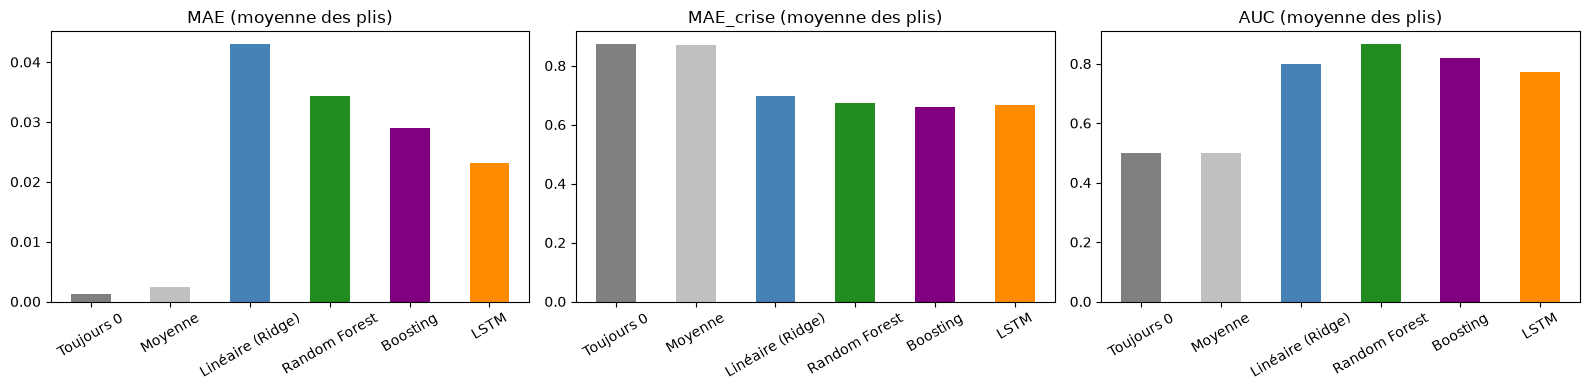

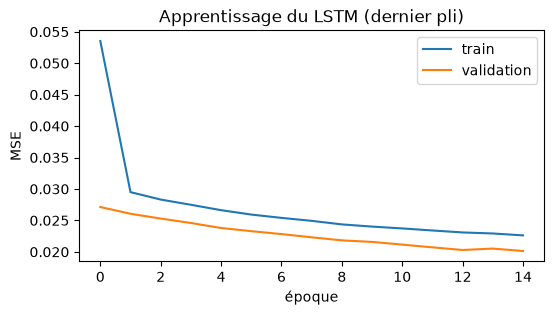

In [85]:
couleurs = ["grey", "silver", "steelblue", "forestgreen", "purple", "darkorange"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metrique in zip(axes, ["MAE", "MAE_crise", "AUC"]):
    resume[metrique].plot.bar(ax=ax, color=couleurs)
    ax.set_title(metrique + " (moyenne des plis)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

# Courbe d'apprentissage du LSTM (dernier pli)
plt.figure(figsize=(6, 3))
plt.plot(historique.history["loss"], label="train")
plt.plot(historique.history["val_loss"], label="validation")
plt.title("Apprentissage du LSTM (dernier pli)")
plt.xlabel("époque")
plt.ylabel("MSE")
plt.legend()
plt.show()

# 10. Importance des features
1. **Ridge** : coefficients (features normalisées, donc comparables).
2. **Random Forest** : importance des arbres (`feature_importances_`).
3. **Permutation** (même méthode pour tous les modèles) : baisse de l'AUC quand on mélange une feature.

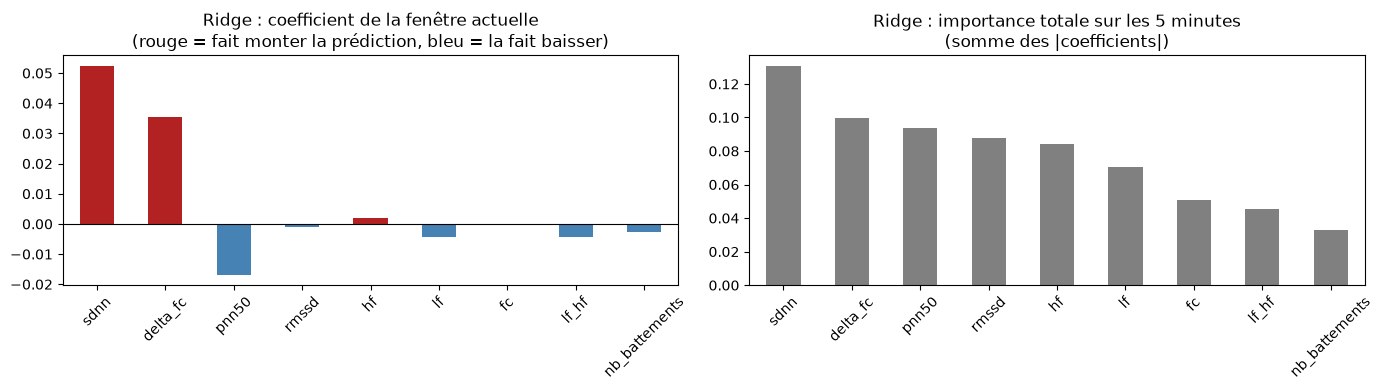

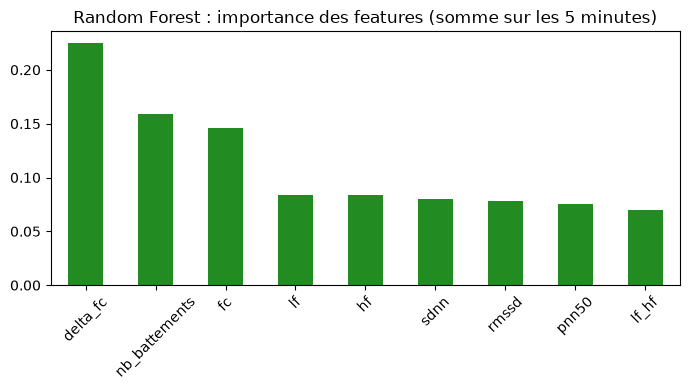

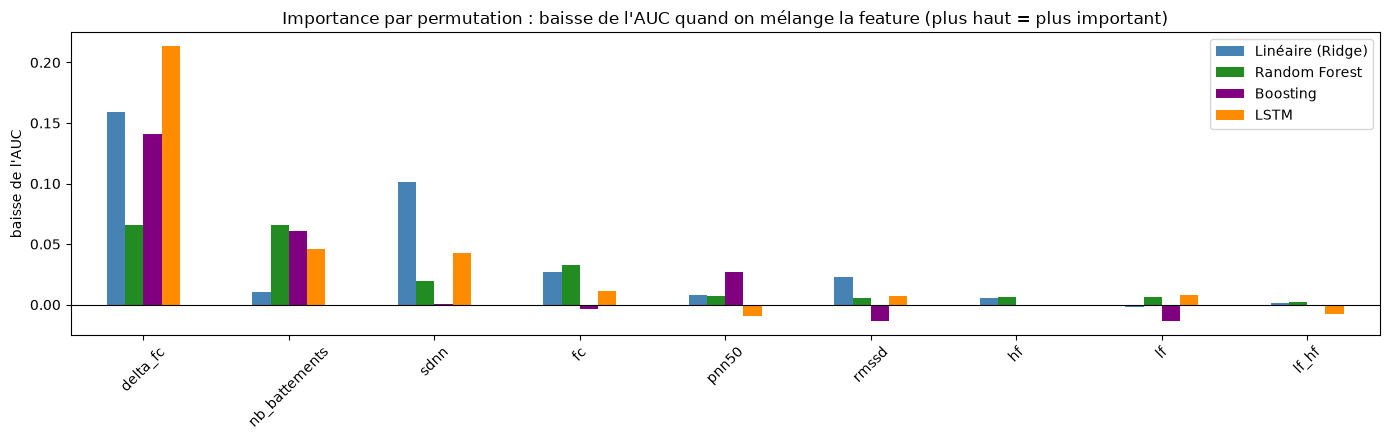

Classement des features (rang 1 = la plus importante) :


,Linéaire (Ridge),Random Forest,Boosting,LSTM
delta_fc,1,2,1,1
nb_battements,5,1,2,2
sdnn,2,4,4,3
fc,3,3,7,4
pnn50,6,5,3,9
rmssd,4,8,8,6
hf,7,6,6,7
lf,9,7,9,5
lf_hf,8,9,5,8


In [86]:
# ============ 1. Modèle linéaire : les coefficients ============
# Les features sont normalisées (même échelle), donc on peut comparer les coefficients entre eux.
# coef_ a 120 valeurs (30 fenêtres x 4 features) : on les remet en tableau (30, 4).
coefs = pd.DataFrame(lineaire.coef_.reshape(LONGUEUR_SEQUENCE, len(NOMS_FEATURES)), columns=NOMS_FEATURES)

importance_lineaire = pd.DataFrame({
    "coef_maintenant": coefs.iloc[-1],              # coefficient de la fenêtre actuelle (avec son signe)
    "somme_abs_5min": coefs.abs().sum(),            # importance totale sur les 5 minutes
}).sort_values("somme_abs_5min", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
importance_lineaire["coef_maintenant"].plot.bar(
    ax=axes[0], color=["firebrick" if v > 0 else "steelblue" for v in importance_lineaire["coef_maintenant"]])
axes[0].set_title("Ridge : coefficient de la fenêtre actuelle\n(rouge = fait monter la prédiction, bleu = la fait baisser)")
axes[0].axhline(0, color="black", linewidth=0.8)
importance_lineaire["somme_abs_5min"].plot.bar(ax=axes[1], color="grey")
axes[1].set_title("Ridge : importance totale sur les 5 minutes\n(somme des |coefficients|)")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


# ============ 2. Random Forest : importance des arbres (comme dans la doc scikit-learn) ============
# feature_importances_ a 120 valeurs : on additionne les 30 fenêtres de chaque feature.
importance_foret = pd.Series(
    foret.feature_importances_.reshape(LONGUEUR_SEQUENCE, len(NOMS_FEATURES)).sum(axis=0),
    index=NOMS_FEATURES).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
importance_foret.plot.bar(color="forestgreen")
plt.title("Random Forest : importance des features (somme sur les 5 minutes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============ 3. Importance par permutation : la même méthode pour TOUS les modèles ============
# Idée : on "mélange" une feature entre les séquences du test (elle ne veut plus rien dire),
# et on regarde de combien l'AUC baisse. Plus elle baisse, plus le modèle avait besoin de cette feature.
def importance_permutation(predire, X_test, y_test, n_repetitions=3):
    rng = np.random.default_rng(GRAINE)
    crise = y_test > 0
    auc_reference = roc_auc_score(crise, predire(X_test))
    baisses = {}
    for j, nom in enumerate(NOMS_FEATURES):
        b = []
        for _ in range(n_repetitions):
            X_melange = X_test.copy()
            X_melange[:, :, j] = X_test[rng.permutation(len(X_test)), :, j]   # on mélange cette feature seulement
            b.append(auc_reference - roc_auc_score(crise, predire(X_melange)))
        baisses[nom] = np.mean(b)
    return pd.Series(baisses)


# Sur le test du dernier pli (X_test, y_test sont ceux du dernier tour de la boucle)
permutation = pd.DataFrame({
    "Linéaire (Ridge)": importance_permutation(lambda X: predire_lineaire(lineaire, X), X_test, y_test),
    "Random Forest": importance_permutation(lambda X: predire_arbres(foret, X), X_test, y_test),
    "Boosting": importance_permutation(lambda X: predire_arbres(boosting, X), X_test, y_test),
    "LSTM": importance_permutation(lambda X: lstm.predict(X, batch_size=2048, verbose=0).ravel(), X_test, y_test),
})
permutation = permutation.loc[permutation.mean(axis=1).sort_values(ascending=False).index]

permutation.plot.bar(figsize=(14, 4.5), color=["steelblue", "forestgreen", "purple", "darkorange"])
plt.title("Importance par permutation : baisse de l'AUC quand on mélange la feature (plus haut = plus important)")
plt.ylabel("baisse de l'AUC")
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Classement des features (rang 1 = la plus importante) :")
permutation.rank(ascending=False).astype(int)

# 11. Prédiction des crises
LSTM du dernier pli, prédit sur toute sa partie test. Alarme si la prédiction dépasse le seuil.

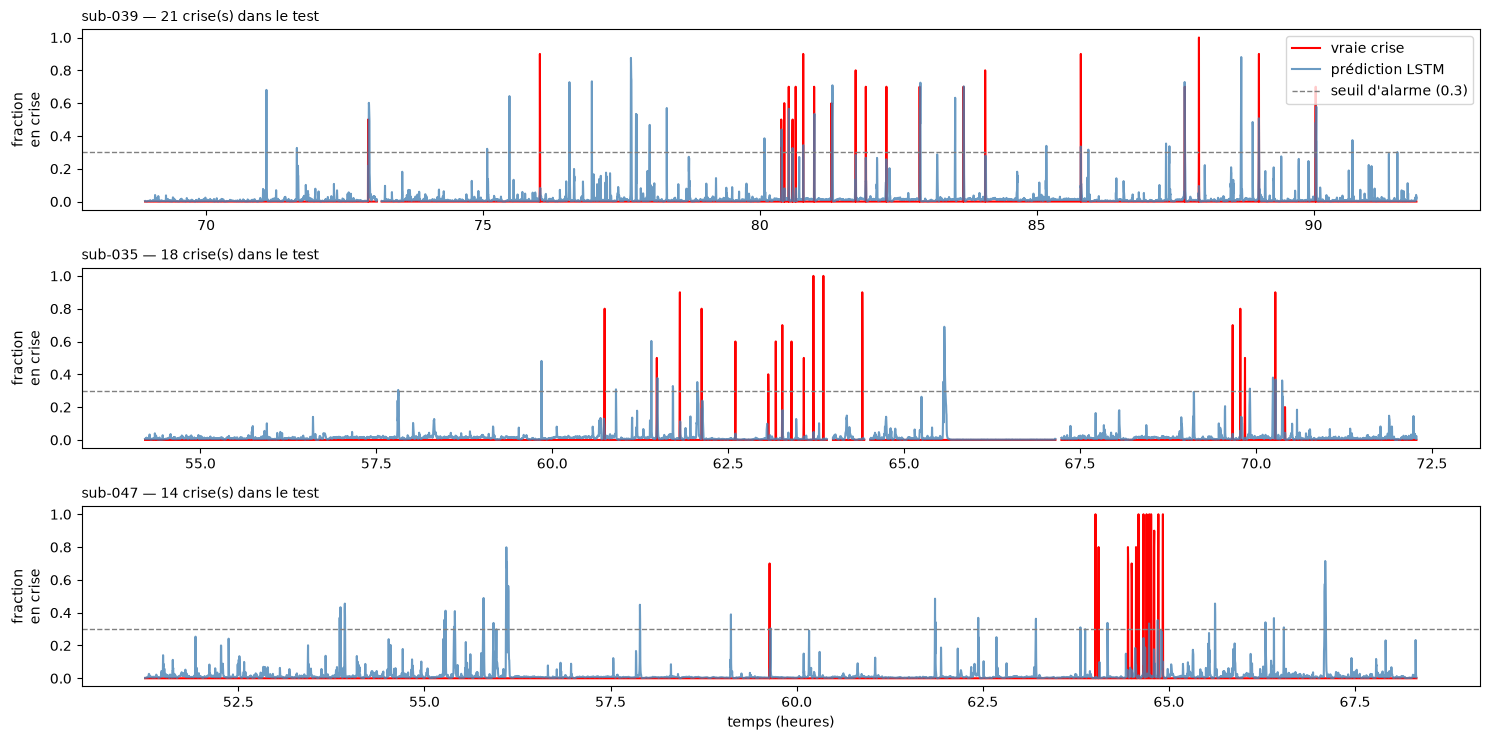

Bilan sur 124 patients :
Seuil 0.3 : 64/176 crises détectées (36 %) | 25.5 fausses alarmes par 24 h
Seuil 0.5 : 47/176 crises détectées (27 %) | 11.7 fausses alarmes par 24 h
Seuil 0.7 : 37/176 crises détectées (21 %) | 5.5 fausses alarmes par 24 h


In [87]:
def tracer_patients(pred, y_vrai, patients, temps_h, nom_modele, seuil=0.5, nb_patients=3, fichier=None):
    """Un graphique par patient : vraie crise, prédiction du modèle et seuil d'alarme.
    On montre seulement les nb_patients qui ont le plus de crises dans le test."""
    # Nombre de crises de chaque patient dans le test (une crise = un bloc de fenêtres en crise)
    nb_crises_test = {}
    for patient in np.unique(patients):
        en_crise = (y_vrai[patients == patient] > 0).astype(int)
        nb_crises_test[patient] = (np.diff(np.r_[0, en_crise]) == 1).sum()
    liste = pd.Series(nb_crises_test).sort_values(ascending=False).index[:nb_patients]

    fig, axes = plt.subplots(len(liste), 1, figsize=(15, 2.5 * len(liste)), squeeze=False)
    for ax, patient in zip(axes[:, 0], liste):
        choix = patients == patient
        t = temps_h[choix]
        y = y_vrai[choix].astype(float)
        p = pred[choix].astype(float)
        saut = np.r_[False, np.diff(t) > 1.5 * DUREE_FENETRE / 3600]   # trou entre deux runs
        y[saut] = np.nan                                                # NaN = matplotlib coupe la ligne
        p[saut] = np.nan
        ax.plot(t, y, color="red", label="vraie crise")
        ax.plot(t, p, color="steelblue", alpha=0.8, label=f"prédiction {nom_modele}")
        ax.axhline(seuil, color="grey", linestyle="--", linewidth=1, label=f"seuil d'alarme ({seuil})")
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f"{patient} — {nb_crises_test[patient]} crise(s) dans le test", loc="left", fontsize=10)
        ax.set_ylabel("fraction\nen crise")
    axes[0, 0].legend(loc="upper right")
    axes[-1, 0].set_xlabel("temps (heures)")
    plt.tight_layout()
    if fichier:
        plt.savefig(fichier, dpi=300, bbox_inches="tight")
    plt.show()


def bilan_alarmes(pred, y_vrai, patients, seuil):
    """Alarme si la prédiction dépasse le seuil. Compte les crises détectées et les fausses alarmes."""
    alarme = pred >= seuil
    crise = y_vrai > 0
    nouveau_patient = np.r_[True, patients[1:] != patients[:-1]]
    # Une crise = un bloc de fenêtres en crise qui se suivent
    debut_crise = crise & ~(np.r_[False, crise[:-1]] & ~nouveau_patient)
    numero_crise = np.cumsum(debut_crise)
    numeros = np.unique(numero_crise[crise])
    detectees = sum(alarme[crise & (numero_crise == n)].any() for n in numeros)
    # Une fausse alarme = un bloc d'alarmes en dehors des crises
    fausse = alarme & ~crise
    debut_fausse = fausse & ~(np.r_[False, fausse[:-1]] & ~nouveau_patient)
    heures = len(y_vrai) * DUREE_FENETRE / 3600
    print(f"Seuil {seuil} : {detectees}/{len(numeros)} crises détectées "
          f"({100 * detectees / max(1, len(numeros)):.0f} %) | "
          f"{debut_fausse.sum() / heures * 24:.1f} fausses alarmes par 24 h")


# ---------- Prédictions du LSTM du DERNIER pli sur tout son test ----------
fins_test_complet = np.array(plis[-1]["test"])[fin_possible[plis[-1]["test"]]]   # toutes les séquences, sans PAS_TEST
morceaux = np.array_split(fins_test_complet, 20)                                  # par morceaux, pour la RAM
pred_final = np.concatenate([
    lstm.predict(construire_sequences(X, m)[0], batch_size=2048, verbose=0).ravel() for m in morceaux
])
y_final = donnees["cible"].to_numpy(dtype=np.float32)[fins_test_complet + HORIZON]
patients_final = donnees["patient"].to_numpy()[fins_test_complet]
temps_final_h = donnees["temps_patient_s"].to_numpy()[fins_test_complet + HORIZON] / 3600

# ---------- Résultats ----------
tracer_patients(pred_final, y_final, patients_final, temps_final_h, "LSTM",
                fichier="figures/predictions_lstm.png", seuil=0.3)
print(f"Bilan sur {len(np.unique(patients_final))} patients :")
for seuil in [0.3, 0.5, 0.7]:
    bilan_alarmes(pred_final, y_final, patients_final, seuil)

# 12. Analyse exploratoire : avant les crises (toutes les features)
Analyse en plus (non utilisée par les modèles) : les features changent-elles dans les minutes qui précèdent une crise ?

interictal    4026769
preictal        23705
ictal            5787


,préictal : changement médian,préictal : % patients en hausse,ictal : changement médian,ictal : % patients en hausse
fc,-0.11,38.71,1.42,87.10
delta_fc,-0.00,47.58,2.07,87.90
nb_battements,0.00,32.26,0.51,57.26
sdnn,0.03,53.23,0.83,91.94
rmssd,0.02,54.03,0.33,70.16
pnn50,0.09,54.03,0.11,54.03
lf,0.01,57.26,0.05,62.10
hf,0.01,52.42,0.02,59.68
lf_hf,-0.02,43.55,0.03,52.42


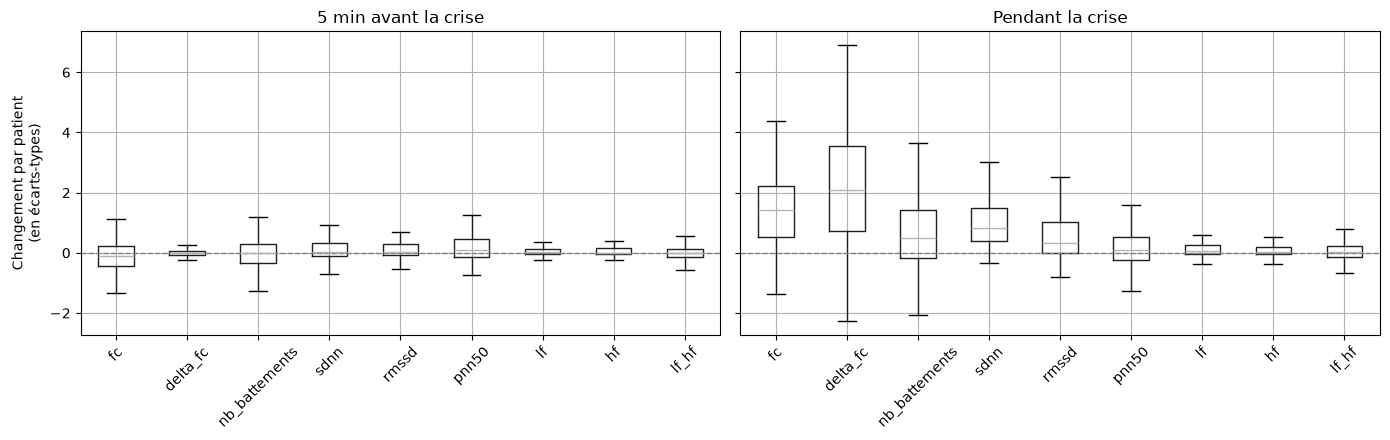

In [88]:
# ============ Analyse exploratoire : les features changent-elles avant les crises ? ============
N_PREICTAL = 30     # 5 minutes avant la crise = 30 fenêtres de 10 s
features_expl = ["fc", "delta_fc", "nb_battements", "sdnn", "rmssd", "pnn50", "lf", "hf", "lf_hf"]

# 1. Phase de chaque fenêtre : interictal (loin des crises), préictal (5 min avant), ictal (pendant)
phase = pd.Series("interictal", index=donnees.index)
phase[donnees["cible"] > 0] = "ictal"
for _, groupe in donnees.groupby(["patient", "run"], sort=False):          # run par run
    crise = groupe["cible"].to_numpy() > 0
    debuts = np.where(crise & ~np.r_[False, crise[:-1]])[0]               # débuts de crise
    for d in debuts:
        avant = groupe.index[max(0, d - N_PREICTAL):d]
        phase[avant[phase[avant] != "ictal"]] = "preictal"                 # on n'écrase pas une crise
print(phase.value_counts().to_string())

# 2. Pour chaque patient : (médiane de la phase - médiane interictale) / écart-type interictal
medianes = donnees[features_expl].groupby([donnees["patient"], phase]).median()
inter = medianes.xs("interictal", level=1)
ecart = donnees.loc[phase == "interictal", features_expl].groupby(donnees["patient"]).std()
changement = {p: (medianes.xs(p, level=1) - inter) / ecart for p in ["preictal", "ictal"]}

# 3. Tableau résumé
resume = pd.DataFrame({
    "préictal : changement médian": changement["preictal"].median(),
    "préictal : % patients en hausse": 100 * (changement["preictal"] > 0).mean(),
    "ictal : changement médian": changement["ictal"].median(),
    "ictal : % patients en hausse": 100 * (changement["ictal"] > 0).mean(),
})
display(resume.round(2))

# 4. Un seul graphique : préictal et ictal côte à côte
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, p, titre in zip(axes, ["preictal", "ictal"], ["5 min avant la crise", "Pendant la crise"]):
    changement[p].boxplot(ax=ax, showfliers=False)
    ax.axhline(0, color="grey", linestyle="--", linewidth=1)
    ax.set_title(titre)
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("Changement par patient\n(en écarts-types)")
plt.tight_layout()
plt.savefig("figures/analyse_preictale.png", dpi=300, bbox_inches="tight")
plt.show()

852 crises alignées, 120 patients


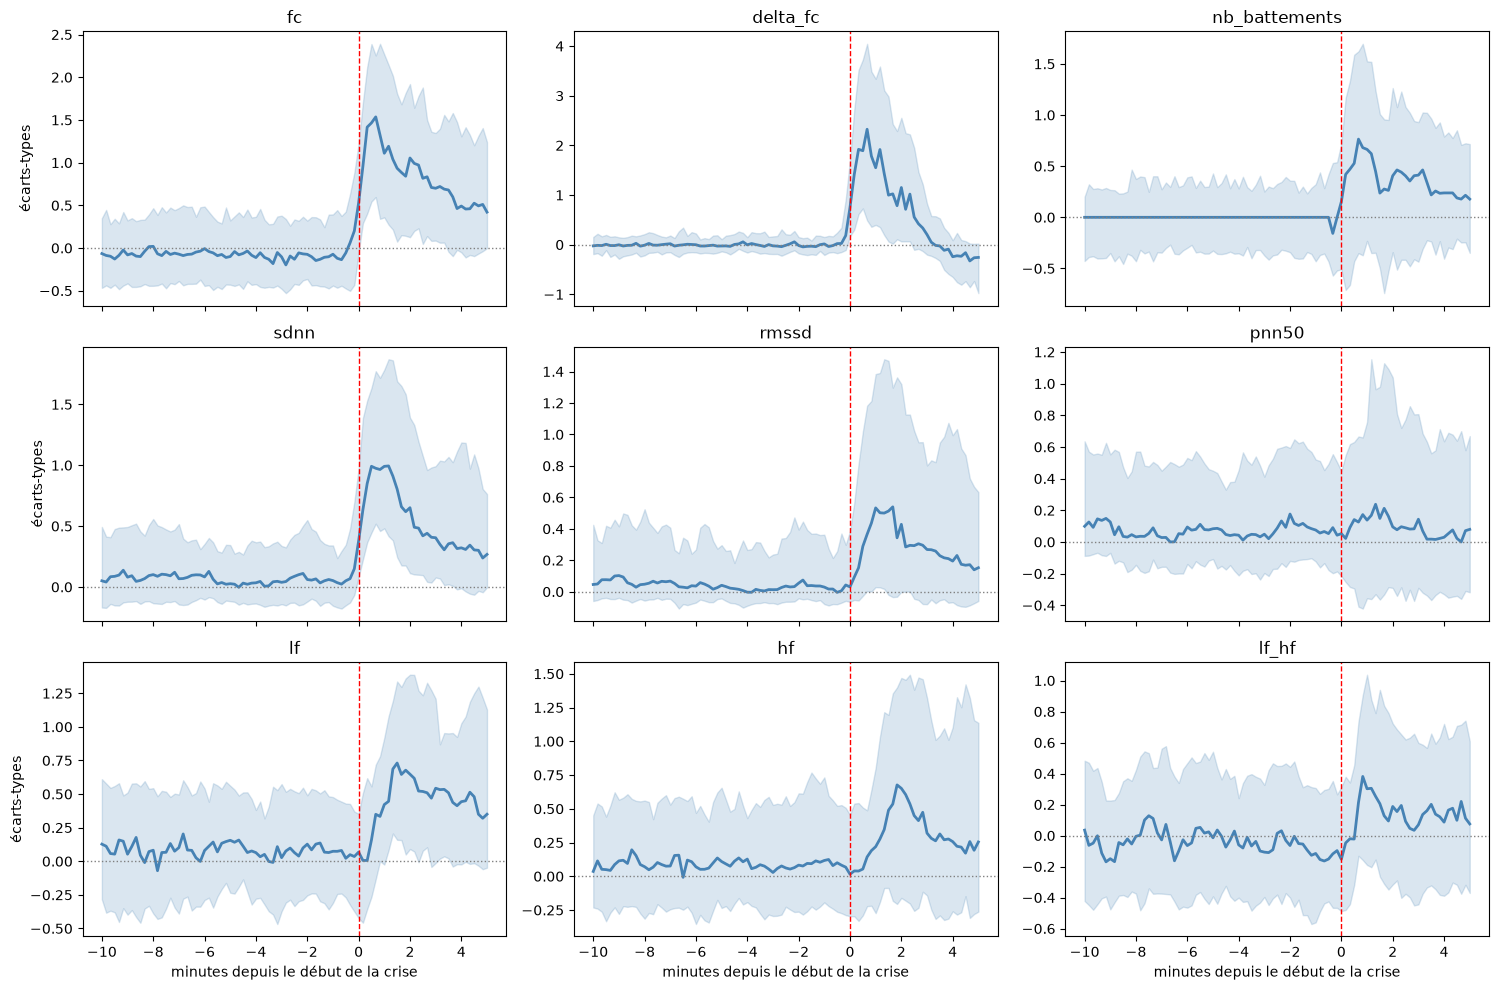

,-10 à -5 min,-5 à -2 min,-2 à 0 min,0 à +1 min,+1 à +5 min
fc,-0.08 (45 %),-0.09 (41 %),-0.09 (43 %),1.31 (84 %),0.75 (82 %)
delta_fc,-0.01 (41 %),0.0 (50 %),-0.0 (49 %),1.67 (90 %),0.2 (68 %)
nb_battements,0.0 (32 %),0.0 (33 %),0.0 (35 %),0.44 (62 %),0.45 (61 %)
sdnn,0.08 (61 %),0.03 (58 %),0.05 (58 %),0.91 (92 %),0.45 (87 %)
rmssd,0.04 (62 %),0.01 (52 %),0.04 (57 %),0.21 (70 %),0.3 (74 %)
pnn50,0.06 (57 %),0.07 (57 %),0.06 (57 %),0.1 (55 %),0.05 (52 %)
lf,0.06 (55 %),0.05 (55 %),0.11 (57 %),0.13 (60 %),0.52 (84 %)
hf,0.09 (55 %),0.08 (57 %),0.11 (58 %),0.08 (55 %),0.32 (69 %)
lf_hf,-0.0 (49 %),-0.05 (48 %),-0.13 (40 %),0.1 (57 %),0.21 (57 %)


In [89]:
# ============ Évolution des features autour du début des crises (-10 min à +5 min) ============
AVANT, APRES = 60, 30            # 60 fenêtres = 10 min avant, 30 fenêtres = 5 min après
feats = ["fc", "delta_fc", "nb_battements", "sdnn", "rmssd", "pnn50", "lf", "hf", "lf_hf"]

# 1. Changement par rapport au niveau habituel du patient (en écarts-types interictaux)
valeurs_expl = donnees[feats].copy()
valeurs_expl[["lf", "hf", "lf_hf"]] = np.log1p(valeurs_expl[["lf", "hf", "lf_hf"]])   # valeurs très étalées
reference = valeurs_expl[phase == "interictal"].groupby(donnees["patient"])
Z = ((valeurs_expl - reference.median().reindex(donnees["patient"]).to_numpy())
     / reference.std().reindex(donnees["patient"]).to_numpy())

# 2. On aligne toutes les crises sur leur début (t = 0)
morceaux = []
for (patient, run), groupe in donnees.groupby(["patient", "run"], sort=False):
    crise = groupe["cible"].to_numpy() > 0
    for d in np.where(crise & ~np.r_[False, crise[:-1]])[0]:                     # débuts de crise
        pos = np.arange(max(0, d - AVANT), min(len(groupe), d + APRES + 1))
        morceau = Z.loc[groupe.index[pos]].copy()
        morceau["patient"] = patient
        morceau["t"] = (pos - d) * DUREE_FENETRE / 60                             # minutes depuis le début
        morceaux.append(morceau)
aligne = pd.concat(morceaux)
print(f"{len(morceaux)} crises alignées, {aligne['patient'].nunique()} patients")

# 3. Médiane des crises de chaque patient, puis médiane entre patients (chaque patient compte pareil)
par_patient = aligne.groupby(["patient", "t"])[feats].median()
courbes = par_patient.groupby("t")
mediane, q1, q3 = courbes.median(), courbes.quantile(0.25), courbes.quantile(0.75)

# 4. Un seul graphique : une petite courbe par feature
fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True)
for ax, f in zip(axes.ravel(), feats):
    ax.fill_between(mediane.index, q1[f], q3[f], alpha=0.2, color="steelblue")
    ax.plot(mediane.index, mediane[f], color="steelblue", linewidth=2)
    ax.axvline(0, color="red", linestyle="--", linewidth=1)       # début de la crise
    ax.axhline(0, color="grey", linestyle=":", linewidth=1)       # niveau habituel
    ax.set_title(f)
for ax in axes[-1]:
    ax.set_xlabel("minutes depuis le début de la crise")
for ax in axes[:, 0]:
    ax.set_ylabel("écarts-types")
plt.tight_layout()
plt.savefig("figures/features_autour_crises.png", dpi=300, bbox_inches="tight")
plt.show()

# 5. Tableau par période : changement médian (et % de patients en hausse)
periodes = pd.cut(par_patient.index.get_level_values("t"), [-10.01, -5, -2, 0, 1, 5.01], right=False,
                  labels=["-10 à -5 min", "-5 à -2 min", "-2 à 0 min", "0 à +1 min", "+1 à +5 min"])
par_periode = par_patient.groupby([par_patient.index.get_level_values("patient"), periodes], observed=True).median()
med = par_periode.groupby(level=1, observed=True).median()
hausse = (par_periode > 0).groupby(level=1, observed=True).mean() * 100
display((med.round(2).astype(str) + " (" + hausse.round(0).astype(int).astype(str) + " %)").T)

# 13. Expérience : prédire à partir de l'ECG brut (sans features)

Au lieu de calculer des mesures (fc, sdnn...), on donne au modèle le signal ECG lui-même :
- filtré (0,5-30 Hz) et sous-échantillonné à **64 Hz** (pour la RAM) ;
- découpé en **les mêmes fenêtres de 10 s** que les features (mêmes cibles, même TimeSeriesSplit) ;
- chaque fenêtre est normalisée seule (moyenne 0, écart-type 1), donc pas de leakage.

Le modèle voit les **30 dernières secondes** (3 fenêtres = 1 920 points) et c'est un **CNN + LSTM** :
les couches de convolution repèrent des formes dans le signal, puis le LSTM les lit dans l'ordre.

La première exécution est longue (relecture de tous les ECG) et crée le fichier `ecg_brut_64hz.npy` (~470 Mo)
dans le dossier Projet ; ensuite il est relu directement. À ne pas mettre sur GitHub.

In [90]:
from scipy.signal import resample_poly
from math import gcd
from numpy.lib.format import open_memmap
import gc

# ---------- Paramètres ----------
N_PATIENTS_BRUT = 50      # l'ECG brut est lourd : on garde les 50 patients avec le plus de crises
FS_BRUT = 64              # on sous-échantillonne l'ECG à 64 points par seconde (au lieu de 256)
POINTS_FENETRE = DUREE_FENETRE * FS_BRUT      # 10 s x 64 = 640 points par fenêtre
FICHIER_BRUT = os.path.join(os.path.dirname(DOSSIER_DATA), f"ecg_brut_64hz_{N_PATIENTS_BRUT}patients.npy")
RECALCULER_BRUT = False   # mettre True pour refaire l'extraction

# ---------- Les 50 patients choisis ----------
patients_brut = (recap_patients.loc[recap_patients.index.isin(donnees["patient"].unique())]
                 .sort_values("nb_crises", ascending=False).index[:N_PATIENTS_BRUT].tolist())
dans_brut = donnees["patient"].isin(patients_brut).to_numpy()   # True si la fenêtre appartient à un des 50 patients
N_FENETRES_BRUT = int(dans_brut.sum())   # int() : un vrai nombre Python, sinon l'en-tête du fichier .npy est illisible

# Lien entre les lignes de "donnees" et les lignes de "ecg_brut" (qui ne contient que les 50 patients)
ligne_brut = np.full(len(donnees), -1)
ligne_brut[dans_brut] = np.arange(N_FENETRES_BRUT)
print(f"{len(patients_brut)} patients | {N_FENETRES_BRUT} fenêtres | "
      f"fichier prévu : {N_FENETRES_BRUT * POINTS_FENETRE * 2 / 1e9:.1f} Go")


def ecg_brut_run(tsv, n_fenetres):
    """Charge l'ECG d'une run, le filtre, le sous-échantillonne à 64 Hz
    et le découpe en n_fenetres fenêtres de 10 s (les MÊMES fenêtres que dans 'donnees')."""
    temps, signal, canal = charger_ecg(fichier_ecg(tsv), 0, np.inf)
    fs = round(1 / (temps[1] - temps[0]))
    signal = np.nan_to_num(signal)
    del temps
    # Filtre 0,5-30 Hz : enlève la dérive lente et le bruit rapide
    sos = butter(3, [0.5, 30], btype="bandpass", fs=fs, output="sos")
    signal = sosfiltfilt(sos, signal)
    # Sous-échantillonnage à 64 Hz
    g = gcd(FS_BRUT, fs)
    signal = resample_poly(signal, FS_BRUT // g, fs // g)
    # Découpage en fenêtres de 640 points (on complète par des 0 si la fin est un peu courte)
    signal = np.pad(signal, (0, max(0, n_fenetres * POINTS_FENETRE - len(signal))))
    fenetres = signal[:n_fenetres * POINTS_FENETRE].reshape(n_fenetres, POINTS_FENETRE)
    # Normalisation fenêtre par fenêtre (chaque fenêtre seule : pas de leakage)
    fenetres = (fenetres - fenetres.mean(axis=1, keepdims=True)) / (fenetres.std(axis=1, keepdims=True) + 1e-8)
    return np.clip(fenetres, -10, 10).astype(np.float16)


def fichier_brut_valide():
    """True si le fichier existe, est lisible et a le bon nombre de lignes."""
    try:
        return np.load(FICHIER_BRUT, mmap_mode="r").shape == (N_FENETRES_BRUT, POINTS_FENETRE)
    except Exception:            # fichier absent, incomplet ou en-tête illisible
        return False


# ---------- Extraction (ou relecture si déjà faite) ----------
if fichier_brut_valide() and not RECALCULER_BRUT:
    ecg_brut = np.load(FICHIER_BRUT, mmap_mode="r")      # lu depuis le disque, sans tout charger en RAM
    print("ECG brut relu depuis", FICHIER_BRUT)
else:
    # On ferme et on supprime un éventuel ancien fichier (sinon Windows refuse de le réécrire)
    ecg_brut = None
    gc.collect()
    if os.path.exists(FICHIER_BRUT):
        os.remove(FICHIER_BRUT)

    # Tableau écrit directement sur le disque au fur et à mesure, pas en RAM
    ecg_brut = open_memmap(FICHIER_BRUT, mode="w+", dtype=np.float16, shape=(N_FENETRES_BRUT, POINTS_FENETRE))
    # Runs dans le MÊME ordre que dans "donnees" : la ligne i de ecg_brut = la i-ème fenêtre des 50 patients
    groupes = donnees[dans_brut].groupby(["patient", "run"], sort=False).indices
    for i, ((patient, run), lignes) in enumerate(groupes.items()):
        print(f"[{i + 1}/{len(groupes)}] {patient} run {run}")
        try:
            tsv = glob.glob(os.path.join(dossier_eeg(patient), f"*_run-{run}_events.tsv"))[0]
            ecg_brut[lignes] = ecg_brut_run(tsv, len(lignes))
        except Exception as erreur:                       # une run qui plante reste à 0, sans tout arrêter
            print(f"   Erreur : {erreur}")
    ecg_brut.flush()                                      # s'assure que tout est bien écrit sur le disque
    del ecg_brut
    gc.collect()
    ecg_brut = np.load(FICHIER_BRUT, mmap_mode="r")
    print("ECG brut enregistré dans", FICHIER_BRUT)

print(ecg_brut.shape, "->", N_FENETRES_BRUT, "fenêtres de", POINTS_FENETRE, "points")

50 patients | 1674895 fenêtres | fichier prévu : 2.1 Go
ECG brut relu depuis C:\Users\Alina\Desktop\AMU\DESU Data science\Projet\ecg_brut_64hz_50patients.npy
(1674895, 640) -> 1674895 fenêtres de 640 points


### Séquences et modèle CNN-LSTM

In [91]:
# ---------- Paramètres ----------
FENETRES_BRUT = 3                 # le modèle voit les 3 dernières fenêtres = 30 s d'ECG (1 920 points)
HORIZON_BRUT = 0                  # 0 = détecter la crise en cours (doit être égal à HORIZON pour comparer)
NEGATIFS_PAR_POSITIF_BRUT = 5     # moins que pour les features : les données brutes prennent beaucoup de RAM

# Fins de séquence possibles : 3 fenêtres dans la même run
fin_possible_brut = (position >= FENETRES_BRUT - 1) & (position + HORIZON_BRUT < taille_run)


def construire_sequences_brut(fins):
    """X : (nb_sequences, 1920, 1) = 30 s d'ECG à 64 Hz ; y : la cible de la dernière fenêtre.
    "fins" sont des lignes de "donnees" : ligne_brut les traduit en lignes de "ecg_brut"."""
    decalages = np.arange(-FENETRES_BRUT + 1, 1)                                         # -2, -1, 0
    X = np.asarray(ecg_brut[ligne_brut[fins[:, None] + decalages]], dtype=np.float32)   # (n, 3, 640)
    X = X.reshape(len(fins), FENETRES_BRUT * POINTS_FENETRE, 1)                          # (n, 1920, 1)
    y = donnees["cible"].to_numpy(dtype=np.float32)[fins + HORIZON_BRUT]
    return X, y


def pli_des_50(pli):
    """Garde seulement les lignes des 50 patients de l'expérience sur ECG brut."""
    train, test = np.array(pli["train"]), np.array(pli["test"])
    return {"train": train[dans_brut[train]], "test": test[dans_brut[test]]}


def fins_du_pli_brut(pli):
    """Comme fins_du_pli, mais avec les séquences de 30 s.
    Le test garde EXACTEMENT les mêmes séquences que les modèles sur features (comparaison juste)."""
    rng = np.random.default_rng(GRAINE)
    cible = donnees["cible"].to_numpy()
    fins_train = pli["train"][fin_possible_brut[pli["train"]]]
    fins_test = pli["test"][fin_possible[pli["test"]]]          # même règle que les features -> même test
    positifs = fins_train[cible[fins_train + HORIZON_BRUT] > 0]
    negatifs = fins_train[cible[fins_train + HORIZON_BRUT] == 0]
    n_neg = min(len(negatifs), max(1, len(positifs)) * NEGATIFS_PAR_POSITIF_BRUT)
    fins_train = rng.permutation(np.concatenate([positifs, rng.choice(negatifs, n_neg, replace=False)]))
    return fins_train, fins_test[::PAS_TEST]


def entrainer_cnn_lstm(X_train, y_train):
    """CNN + LSTM sur l'ECG brut :
    - les couches Conv1D 'scannent' le signal et repèrent des formes (pics, rythme, artefacts) ;
    - MaxPooling raccourcit le signal (1920 -> 120 pas de temps) ;
    - le LSTM lit ces 120 pas dans l'ordre ;
    - la sortie est un nombre entre 0 et 1, comme la cible."""
    modele = keras.Sequential([
        keras.Input(shape=(X_train.shape[1], 1)),
        keras.layers.Conv1D(16, kernel_size=7, padding="same", activation="relu"),
        keras.layers.MaxPooling1D(4),                       # 1920 -> 480
        keras.layers.Conv1D(32, kernel_size=7, padding="same", activation="relu"),
        keras.layers.MaxPooling1D(4),                       # 480 -> 120
        keras.layers.LSTM(32),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    modele.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse", metrics=["mae"])
    arret = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    historique = modele.fit(X_train, y_train, validation_split=0.15, epochs=15,
                            batch_size=128, callbacks=[arret], verbose=2)
    return modele, historique

### Entraînement et évaluation sur les 3 plis

In [92]:
resultats_brut = []

for k, pli in enumerate(plis):
    print(f"\n========== Pli {k + 1}/{len(plis)} ({N_PATIENTS_BRUT} patients) ==========")
    pli50 = pli_des_50(pli)          # on garde seulement les 50 patients de l'expérience brute

    # ---------- Modèles sur features, entraînés sur les MÊMES 50 patients ----------
    X_feat = normaliser(pli50["train"])
    fins_train, fins_test = fins_du_pli(pli50)
    X_train, y_train = construire_sequences(X_feat, fins_train)
    X_test, y_test = construire_sequences(X_feat, fins_test)

    # Modèle de référence
    resultats_brut.append(evaluer("Toujours 0", y_test, np.zeros_like(y_test), k + 1))

    # Random Forest et LSTM sur features
    foret_50 = entrainer_foret(X_train, y_train)
    resultats_brut.append(evaluer("Random Forest (features)", y_test, predire_arbres(foret_50, X_test), k + 1))
    lstm_50, _ = entrainer_lstm(X_train, y_train)
    pred_lstm_50 = lstm_50.predict(X_test, batch_size=2048, verbose=0).ravel()
    resultats_brut.append(evaluer("LSTM (features)", y_test, pred_lstm_50, k + 1))
    del X_train, X_test, X_feat, foret_50          # on libère la RAM

    # ---------- CNN-LSTM sur l'ECG brut, testé sur les MÊMES séquences ----------
    fins_train_b, fins_test_b = fins_du_pli_brut(pli50)
    X_train_b, y_train_b = construire_sequences_brut(fins_train_b)
    X_test_b, y_test_b = construire_sequences_brut(fins_test_b)
    print("train brut :", X_train_b.shape, f"({(y_train_b > 0).sum()} avec crise)",
          "| test :", X_test_b.shape, f"({(y_test_b > 0).sum()} avec crise)")

    cnn_lstm, historique_brut = entrainer_cnn_lstm(X_train_b, y_train_b)
    pred_brut = cnn_lstm.predict(X_test_b, batch_size=512, verbose=0).ravel()
    resultats_brut.append(evaluer("CNN-LSTM (ECG brut)", y_test_b, pred_brut, k + 1))
    del X_train_b, X_test_b                        # on libère la RAM avant le pli suivant

resultats_brut = pd.DataFrame(resultats_brut)
resume_brut = resultats_brut.groupby("modele", sort=False)[["MSE", "MAE", "MSE_crise", "MAE_crise", "AUC"]].mean()
resume_brut.round(4)


========== Pli 1/3 (50 patients) ==========
Epoch 1/15
46/46 - 3s - 55ms/step - loss: 0.1013 - mae: 0.2595 - val_loss: 0.0451 - val_mae: 0.1059
Epoch 2/15
46/46 - 1s - 20ms/step - loss: 0.0337 - mae: 0.0733 - val_loss: 0.0377 - val_mae: 0.0745
Epoch 3/15
46/46 - 1s - 20ms/step - loss: 0.0306 - mae: 0.0677 - val_loss: 0.0356 - val_mae: 0.0743
Epoch 4/15
46/46 - 1s - 20ms/step - loss: 0.0296 - mae: 0.0645 - val_loss: 0.0346 - val_mae: 0.0715
Epoch 5/15
46/46 - 1s - 19ms/step - loss: 0.0290 - mae: 0.0639 - val_loss: 0.0336 - val_mae: 0.0702
Epoch 6/15
46/46 - 1s - 19ms/step - loss: 0.0279 - mae: 0.0596 - val_loss: 0.0331 - val_mae: 0.0644
Epoch 7/15
46/46 - 1s - 19ms/step - loss: 0.0270 - mae: 0.0573 - val_loss: 0.0327 - val_mae: 0.0617
Epoch 8/15
46/46 - 1s - 19ms/step - loss: 0.0266 - mae: 0.0574 - val_loss: 0.0321 - val_mae: 0.0601
Epoch 9/15
46/46 - 1s - 19ms/step - loss: 0.0260 - mae: 0.0539 - val_loss: 0.0315 - val_mae: 0.0669
Epoch 10/15
46/46 - 1s - 19ms/step - loss: 0.0250 - mae

,MSE,MAE,MSE_crise,MAE_crise,AUC
modele,,,,,
Toujours 0,0.0022,0.0023,0.7967,0.8491,0.5000
Random Forest (features),0.0055,0.0355,0.5253,0.6685,0.8646
LSTM (features),0.0065,0.0271,0.5505,0.6686,0.7658
CNN-LSTM (ECG brut),0.0161,0.0868,0.4684,0.6145,0.7823


### Comparaison : features vs ECG brut

,MSE,MAE,MSE_crise,MAE_crise,AUC
modele,,,,,
Toujours 0,0.0022,0.0023,0.7967,0.8491,0.5000
Random Forest (features),0.0055,0.0355,0.5253,0.6685,0.8646
LSTM (features),0.0065,0.0271,0.5505,0.6686,0.7658
CNN-LSTM (ECG brut),0.0161,0.0868,0.4684,0.6145,0.7823


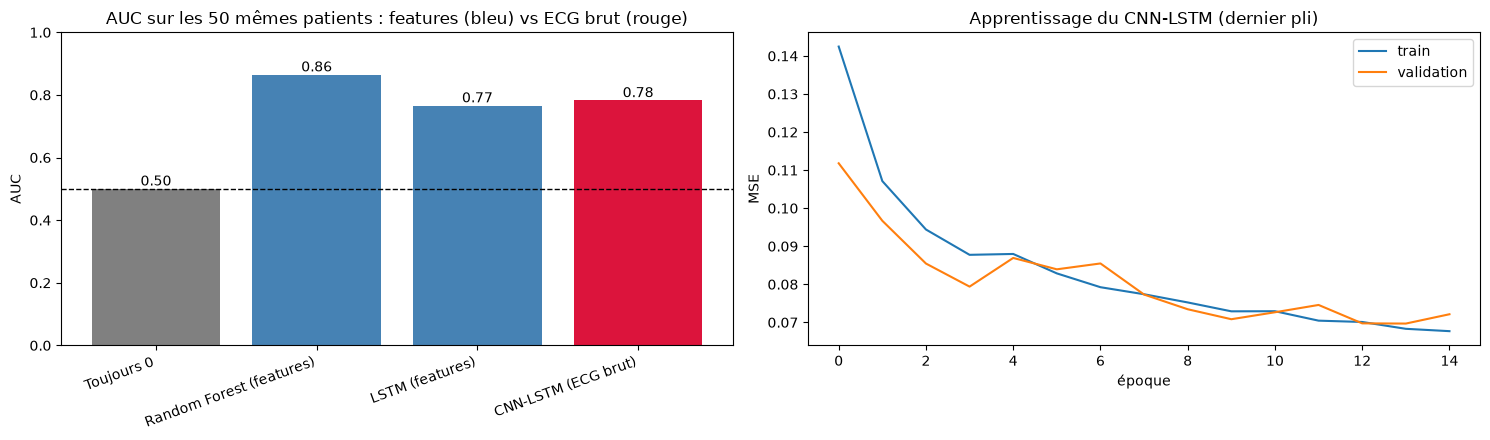

In [95]:
# Comparaison sur les MÊMES 50 patients et les MÊMES séquences de test
comparaison = resume_brut
display(comparaison.round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
couleurs = ["grey" if "Toujours" in m else "crimson" if "brut" in m else "steelblue" for m in comparaison.index]
barres = axes[0].bar(comparaison.index, comparaison["AUC"], color=couleurs)
axes[0].bar_label(barres, fmt="%.2f")                          # valeur au-dessus de chaque barre
axes[0].axhline(0.5, color="black", linestyle="--", linewidth=1)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("AUC")
axes[0].set_title(f"AUC sur les {N_PATIENTS_BRUT} mêmes patients : features (bleu) vs ECG brut (rouge)")
plt.setp(axes[0].get_xticklabels(), rotation=20, ha="right")  # étiquettes inclinées sans se chevaucher

axes[1].plot(historique_brut.history["loss"], label="train")
axes[1].plot(historique_brut.history["val_loss"], label="validation")
axes[1].set_title("Apprentissage du CNN-LSTM (dernier pli)")
axes[1].set_xlabel("époque")
axes[1].set_ylabel("MSE")
axes[1].legend()
plt.tight_layout()
#plt.savefig("figures/comparaison_features_brut.png", dpi=300, bbox_inches="tight")
plt.show()

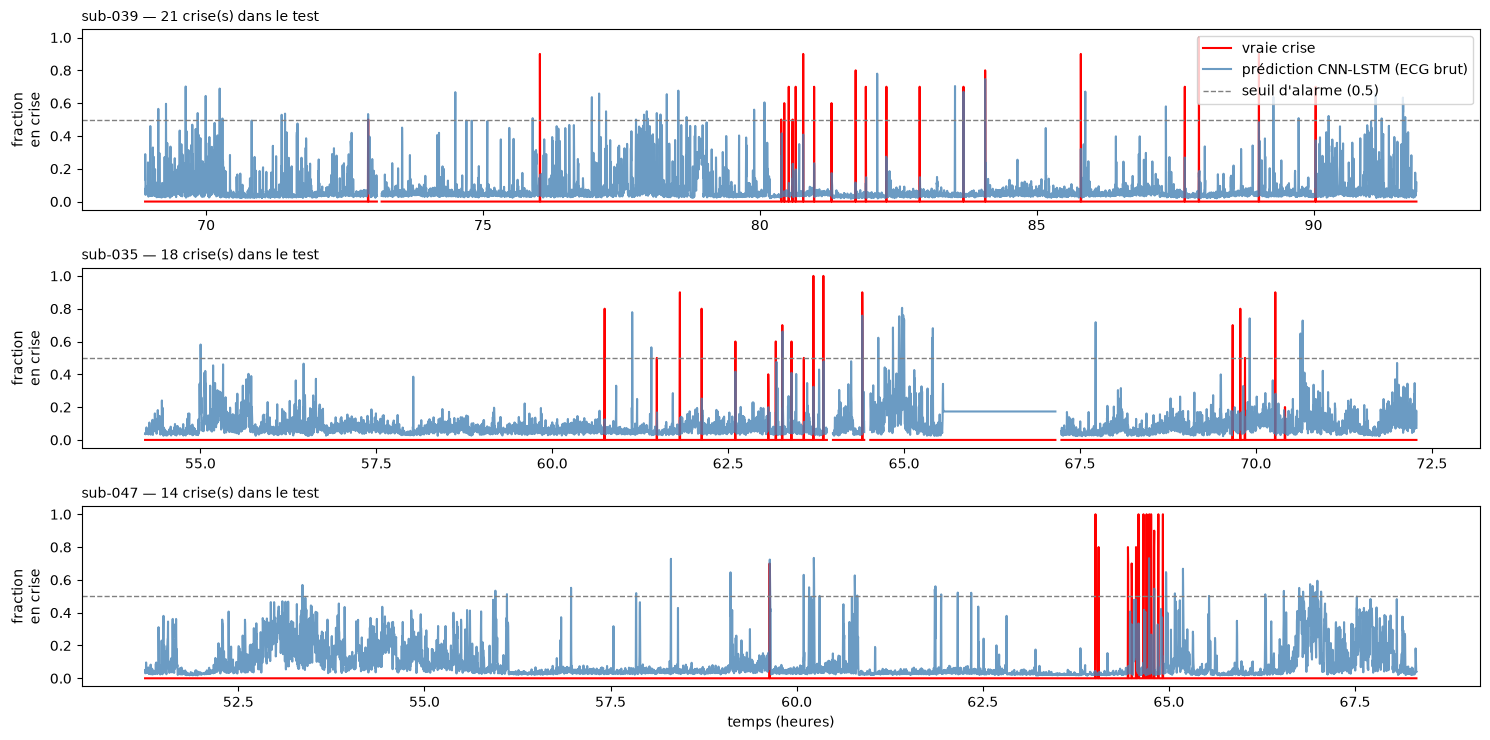

CNN-LSTM (ECG brut) — bilan sur 50 patients :
Seuil 0.3 : 80/149 crises détectées (54 %) | 96.9 fausses alarmes par 24 h
Seuil 0.5 : 53/149 crises détectées (36 %) | 36.3 fausses alarmes par 24 h
Seuil 0.7 : 21/149 crises détectées (14 %) | 10.4 fausses alarmes par 24 h

LSTM (features) — mêmes 50 patients :
Seuil 0.3 : 43/149 crises détectées (29 %) | 20.9 fausses alarmes par 24 h
Seuil 0.5 : 31/149 crises détectées (21 %) | 10.0 fausses alarmes par 24 h
Seuil 0.7 : 19/149 crises détectées (13 %) | 4.4 fausses alarmes par 24 h


In [96]:
# ---------- Dernier pli de l'expérience brute : toutes les séquences de test des 50 patients ----------
pli50_final = pli_des_50(plis[-1])
fins_test_50 = pli50_final["test"][fin_possible[pli50_final["test"]]]   # toutes les séquences, sans PAS_TEST
morceaux_50 = np.array_split(fins_test_50, 20)                          # par morceaux, pour la RAM

# Prédictions du CNN-LSTM sur l'ECG brut
pred_brut_final = np.concatenate([
    cnn_lstm.predict(construire_sequences_brut(m)[0], batch_size=512, verbose=0).ravel() for m in morceaux_50
])

# Prédictions du LSTM sur features (mêmes patients, mêmes séquences)
X_feat_final = normaliser(pli50_final["train"])
pred_lstm50_final = np.concatenate([
    lstm_50.predict(construire_sequences(X_feat_final, m)[0], batch_size=2048, verbose=0).ravel() for m in morceaux_50
])

y_50 = donnees["cible"].to_numpy(dtype=np.float32)[fins_test_50 + HORIZON]
patients_50 = donnees["patient"].to_numpy()[fins_test_50]
temps_50_h = donnees["temps_patient_s"].to_numpy()[fins_test_50 + HORIZON] / 3600

# ---------- Graphique : les 3 patients avec le plus de crises ----------
tracer_patients(pred_brut_final, y_50, patients_50, temps_50_h, "CNN-LSTM (ECG brut)",
                fichier="figures/predictions_cnn_lstm_brut.png")

# ---------- Bilan des alarmes : les deux modèles sur les mêmes patients ----------
print(f"CNN-LSTM (ECG brut) — bilan sur {len(np.unique(patients_50))} patients :")
for seuil in [0.3, 0.5, 0.7]:
    bilan_alarmes(pred_brut_final, y_50, patients_50, seuil)

print(f"\nLSTM (features) — mêmes {len(np.unique(patients_50))} patients :")
for seuil in [0.3, 0.5, 0.7]:
    bilan_alarmes(pred_lstm50_final, y_50, patients_50, seuil)